# Bayesian Optimisation: ERK Oscillation (v7)

**What's new vs v6:**

1. **mean_osc_probability_avg is now a MEDIAN across cells**, not a mean.
   Robust to single-cell outliers that pull the per-FOV aggregate around
   on the sparse-response regime. The column name is kept for back-compat
   with v6 notebooks / checkpoints, but the aggregation is
   np.median(per_cell_mean_prob) under the hood.
2. **Set max_baseline_cnr=0.95** (was 0.8 in v6). All per-FOV aggregates —
   including the new median — are now computed over cells whose
   baseline_cnr (mean CNR across the pre-stim frames) is below 0.95.
   Legitimate responders with slightly elevated baseline can contribute
   while extreme already-active cells are still excluded.
3. **Ref-frame optoRTK fix.** _preprocess_results now drops NaN rows BEFORE
   the per-particle .first() aggregate, so the optoRTK extraction no
   longer silently wipes all cells on some pandas versions. The discard
   warning now also reports *why* a FOV failed (empty / all-zero /
   negative mean).

**Inherits from v6:**
- Extended parameter range: stim_exposure 0-1000 ms (step 25),
  ramp 0-50 ms/frame (step 5)
- initial_exploration_cap=0.7 on the farthest-point initial phases
- optortk_expression declared with log_scale=True

**GP model:** ExactGP + MCMC (gpax), Matern kernel, 5 input dims
(2 controllable + 3 covariates).

In [1]:
import os
import time
import logging
import importlib.util
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Suppress JAX/XLA debug messages
os.environ["JAX_LOG_COMPILES"] = "0"
os.environ["TF_CPP_MIN_LOG_LEVEL"] = "2"

import jax

jax.config.update("jax_log_compiles", False)
for _name in list(logging.Logger.manager.loggerDict):
    if "jax" in _name or "absl" in _name:
        logging.getLogger(_name).setLevel(logging.WARNING)

# ---------------------------------------------------------------------------
# gpax/numpyro compatibility shim
# ---------------------------------------------------------------------------
# numpyro >= 0.20 removed haiku support from numpyro.contrib.module, but
# gpax 0.1.9 eagerly imports viDKL via gpax/models/__init__.py, which tries
# `from numpyro.contrib.module import random_haiku_module, haiku_module`.
# We don't use viDKL (only ExactGP, viGP, viSparseGP), so we install stubs
# that raise only if viDKL is actually called. This MUST run before any
# `import gpax` (including the lazy ones inside the BO agent classes).
import numpyro.contrib.module as _ncm


def _haiku_unavailable(*_args, **_kwargs):
    raise NotImplementedError(
        "haiku support was removed from numpyro >= 0.20. "
        "viDKL is not available. Use ExactGP, viGP, or viSparseGP."
    )


if not hasattr(_ncm, "random_haiku_module"):
    _ncm.random_haiku_module = _haiku_unavailable
if not hasattr(_ncm, "haiku_module"):
    _ncm.haiku_module = _haiku_unavailable
# ---------------------------------------------------------------------------

from faro.core.data_structures import (
    PowerChannel,
    SegmentationMethod,
)
from faro.core.controller import Controller
from faro.core.pipeline import ImageProcessingPipeline
from faro.agents.bo_optimization import (
    BO_Parameter,
    BO_Objective,
    BO_Covariate,
)
from faro.agents.bo_oscillation import OscillationBO
import faro.core.utils as utils

## Microscope & pipeline setup

**Microscope:** Jungfrau (no DMD -- full-FOV stimulation).

**Channels:**
- Imaging: miRFP (nuclear marker) + mScarlet3 (ERK-KTR reporter)
- Stimulation: CyanStim (optogenetic activation, power 10)
- Optocheck: mCitrine (verify optoRTK expression, last frame only)

**Pipeline:** CellposeV4 segmentation -> ERK-KTR FE -> Trackpy tracking
-> OptoCheckFE on reference frames. Full-FOV stimulation (no DMD).

In [1]:
from faro.microscope.pertzlab.jungfrau import Jungfrau

mic = Jungfrau()
mic.mmc.setChannelGroup("TTL_ERK")
mic.mmc.setProperty("TIPFSStatus", "State", "On")

In [2]:
import napari
from napari_micromanager import MainWindow

viewer = napari.Viewer()
mm_wdg = MainWindow(viewer)
mm_wdg._mmc = mic.mmc  # point the widget at our CMMCore instance
viewer.window.add_dock_widget(mm_wdg)  # dock Micro-Manager controls in napari

In [3]:
# --- Experiment parameters ---
TIME_BETWEEN_TIMESTEPS = 60  # seconds (1 frame/min)

# --- Phase layout (frames; 1 frame == 1 minute at TIME_BETWEEN_TIMESTEPS=60) ---
# 10 min baseline -> 60 min stimulation -> 20 min recovery (cool-down).
# The recovery frames are acquired (imaging continues) but no stim events
# fire on them.  The oscillation classifier is restricted by default to
# the stim window only (`classifier_window=(FIRST_FRAME_STIM, LAST_FRAME_STIM)`),
# so baseline + recovery frames are observed but not classified.
N_FRAMES_BASELINE = 10
N_FRAMES_STIM = 60
N_FRAMES_RECOVERY = 20

# Derived (don't edit -- adjust the three above instead).
N_FRAMES = N_FRAMES_BASELINE + N_FRAMES_STIM + N_FRAMES_RECOVERY  # 90
FIRST_FRAME_STIM = N_FRAMES_BASELINE  # 10
LAST_FRAME_STIM = FIRST_FRAME_STIM + N_FRAMES_STIM  # 70

# --- Plate calibration ---
# Path to a WellPlatePlan JSON saved by the pymmcore-widgets MDA plate widget.
PLATE_CALIBRATION_PATH = r"./calib_plate_96.json"  # <-- UPDATE

# --- Wells to use (consumed in chunks of N_WELLS_PER_PHASE per phase) ---
# Supply N_PHASES * N_WELLS_PER_PHASE wells, in the order you want them
# visited.  The FOV finder pops the next chunk on every phase.

WELLS = []
START_COL = 2
END_COL = 12
for i, row in enumerate("ABCD"):
    cols = (
        range(START_COL, END_COL + 1)
        if i % 2 == 0
        else range(END_COL, START_COL - 1, -1)
    )
    WELLS.extend(f"{row}{c}" for c in cols)

# --- FOV finder knobs ---
FOV_BORDER_UM = 1000.0  # keep candidate positions away from well edge
FOV_MIN_DISTANCE_UM = 750.0  # min center-to-center spacing between candidates
FOV_MIN_CELLS = 35  # min cell count for a candidate to be valid
FOV_N_CANDIDATES_PER_WELL = 10  # oversample to give farthest-point room

# --- Phased FOV layout ---
N_WELLS_PER_PHASE = 6  # 6 wells per phase
FOVS_PER_WELL = 3  # 3 fresh FOVs per well per phase
N_FOVS = N_WELLS_PER_PHASE * FOVS_PER_WELL  # 18 FOVs per phase
N_CONDITIONS_PER_ITER = 3  # batch BO: 2 conditions tested per phase
FOVS_PER_CONDITION = N_FOVS // N_CONDITIONS_PER_ITER  # 9
N_PHASES = 12

WELLS = WELLS[
    : N_PHASES * N_WELLS_PER_PHASE
]  # trim to max needed, in case we supplied too many
# assert (
#    len(WELLS) >= N_PHASES * N_WELLS_PER_PHASE
# ), f"Need at least {N_PHASES * N_WELLS_PER_PHASE} wells, got {len(WELLS)}"
# assert (
#    len(WELLS) % N_WELLS_PER_PHASE == 0
# ), f"Number of wells ({len(WELLS)}) must be divisible by N_WELLS_PER_PHASE ({N_WELLS_PER_PHASE}), you need to shorten the WELLS list by {len(WELLS) % N_WELLS_PER_PHASE} wells."


# --- Storage ---
base_path = "E:\\Alex"
experiment_name = "2026-04-15_bo_erk_oscillation_v7"
path = os.path.join(base_path, experiment_name)

# --- Stimulation channel (base -- exposure is overridden by BO) ---
stim_channel = PowerChannel(
    config="CyanStim",
    exposure=100,
    group="TTL_ERK",
    power=10,
)

# --- Imaging channels (acquired every timepoint AND used by FOV finder) ---
imaging_channels = (
    PowerChannel(config="miRFP", exposure=150, group="TTL_ERK", power=95),
    PowerChannel(config="mScarlet3", exposure=150, group="TTL_ERK", power=95),
)

# --- Optocheck channel (acquired on last frame only) ---
optocheck_channel = PowerChannel(
    config="mCitrine",
    exposure=600,
    group="TTL_ERK",
    power=95,
)

In [6]:
len(WELLS) / N_WELLS_PER_PHASE

7.333333333333333

In [4]:
from faro.stimulation.base import StimWholeFOV
from faro.tracking.trackpy import TrackerTrackpy
from faro.feature_extraction.erk_ktr import FE_ErkKtr
from faro.feature_extraction.optocheck import OptoCheckFE
from faro.segmentation.cellpose_v4 import CellposeV4

# A single Cellpose instance is shared by the experiment pipeline AND the
# FOVFinderAgent below.  Reusing the same model avoids loading it twice
# (memory + GPU savings) and guarantees that the FOV finder counts cells
# with exactly the same segmentation the experiment will use.
segmentator = CellposeV4(
    custom_model_path="E:\\models\\cellpose\\LifeActH2B_mixed_with_only_H2B_v1",
    min_size=100,
)

pipeline = ImageProcessingPipeline(
    storage_path=path,
    segmentators=[
        SegmentationMethod(
            name="labels",
            segmentation_class=segmentator,
            use_channel=0,  # segment on miRFP (nuclear marker)
            save_tracked=True,
        )
    ],
    feature_extractor=FE_ErkKtr("labels"),
    tracker=TrackerTrackpy(search_range=50),
    stimulator=StimWholeFOV(),
    feature_extractor_ref=OptoCheckFE(used_mask="labels"),
)

from faro.core.writers import OmeZarrWriter

writer = OmeZarrWriter(storage_path=path)

Directory E:\Alex\2026-04-15_bo_erk_oscillation_v7\tracks already exists


## FOV selection (per-phase, automated)

Instead of manually selecting 18 positions in napari, a `FOVFinderAgent`
(plugged into the generic `ComposedAgent`) picks fresh positions before
**every phase**:

1. The agent loads the plate calibration (`WellPlatePlan` JSON saved by
   the pymmcore-widgets MDA plate widget).
2. It pops the next `N_WELLS_PER_PHASE` (= 6) wells from `WELLS`.
3. For each well it generates `FOV_N_CANDIDATES_PER_WELL` (= 8) random
   candidate positions, kept `FOV_BORDER_UM` µm away from the well edge
   and at least `FOV_MIN_DISTANCE_UM` apart from each other.
4. It snaps the candidates with the segmentation channel only (miRFP)
   via `mic.run_mda` and segments the result with the **same**
   `CellposeV4` instance the experiment pipeline uses (`segmentator`).
5. Candidates with `< FOV_MIN_CELLS` cells are dropped; the remaining
   ones are reduced to `FOVS_PER_WELL` (= 3) per well by greedy
   farthest-point sampling so the picked FOVs do not overlap.

The result (18 fresh FOVs / phase) is fed straight into
`OscillationBO.run_one_phase`, which is wired up by the `ComposedAgent`
in the next sections.

The segmentator was already created in the pipeline cell above and is
reused here -- no extra setup needed.  The `FOVFinderAgent` is constructed
in the *Configure and run* section together with the BO agent and the
composed driver.


## Oscillation classifier

Load the pre-trained sliding-window oscillation classifier. This model uses
FFT, ACF, and time-domain features extracted from the ERK-KTR `cnr` trace
to classify each window as oscillating or not.

The classifier is restricted at runtime to the **stimulation window only**
(via `OscillationBO.classifier_window`, which defaults to
`(FIRST_FRAME_STIM, LAST_FRAME_STIM)`). Baseline and recovery frames are
acquired but not classified.

A cell is classified as **oscillating** if **all** of the following hold
(scored over windows within `[FIRST_FRAME_STIM, LAST_FRAME_STIM]`):

| Metric | Condition |
|---|---|
| FFT amplitude score | >= 0.3 |
| Max osc. probability | >= 0.95 |
| Consecutive osc. windows | >= 3 |

Cells are only included in the `frac_oscillating` calculation if they pass
two quality gates:
- Tracked for >= 90% of the experiment (`min_track_fraction=0.9`)
- Baseline CNR < 0.8 (`max_baseline_cnr=0.8`)

In [5]:
import joblib

# --- Load pre-trained oscillation classifier ---
CLASSIFIER_PATH = r"./oscillation_model_60min.joblib"  # <-- UPDATE THIS PATH

model_data = joblib.load(CLASSIFIER_PATH)
osc_clf = model_data["clf"]
osc_scaler = model_data["scaler"]
osc_feature_cols = model_data["feature_cols"]
osc_cfg = model_data["config"]
osc_cfg["window_size"] = model_data["window_size"]
osc_cfg["window_step"] = model_data["window_step"]

# Import the predict_trace function from the classifier script
_classifier_script = "./apply_oscillation_classifier_v2.py"

_spec = importlib.util.spec_from_file_location("osc_classifier", _classifier_script)
_osc_module = importlib.util.module_from_spec(_spec)
_spec.loader.exec_module(_osc_module)
predict_trace = _osc_module.predict_trace

# --- Oscillation thresholds ---
# A cell is oscillating iff ALL three gates pass (>= for all):
#   1. FFT amplitude score >= 0.3
#   2. Max osc. probability >= 0.95
#   3. Consecutive osc. windows >= 3
MIN_OSC_PROBABILITY = (
    0.0  # v6: gates disabled, BO target is frac_responders (mean prob >= 0.75 per cell)
)
MIN_CONSECUTIVE_WINDOWS = 0
MIN_FFT_AMPLITUDE = 0.0

print(f"Loaded oscillation classifier from {CLASSIFIER_PATH}")
print(f"  Window: {osc_cfg['window_size']} steps, stride {osc_cfg['window_step']}")
print(
    f"  Thresholds: prob >= {MIN_OSC_PROBABILITY}, "
    f"consecutive >= {MIN_CONSECUTIVE_WINDOWS}, "
    f"fft_amplitude >= {MIN_FFT_AMPLITUDE}"
)

Loaded oscillation classifier from ./oscillation_model_60min.joblib
  Window: 20 steps, stride 5
  Thresholds: prob >= 0.0, consecutive >= 0, fft_amplitude >= 0.0


## Batch BO agent

The :class:`OscillationBO` subclass of :class:`BOptGPAX` lives in
``faro.agents.bo_oscillation``.  It overrides:

- ``_create_events_for_batch`` -- builds RTMEvents for ``N_FOVS`` FOVs across
  ``N_CONDITIONS_PER_ITER`` conditions (``FOVS_PER_CONDITION`` each), applying
  per-frame ramped stim exposure.
- ``_preprocess_results`` -- runs the oscillation classifier on each cell's
  ``cnr`` trace (sliced to the stimulation window via ``classifier_window``)
  and computes the per-FOV oscillating fraction. Also computes the
  ``baseline_cnr`` covariate from the first ``n_baseline_frames``.
- ``_on_phase_complete`` -- live plotting + checkpoint saving + saves the
  trained GP to ``{storage_path}/bo_model.joblib`` for post-hoc analysis.

All batch-BO machinery (sequential greedy acquisition with local penalisation,
FOV-index offsetting across phases, ``run_one_phase`` integration with
``ComposedAgent``) is inherited from ``BOptGPAX``.  See
[faro/agents/bo_oscillation.py](../../faro/agents/bo_oscillation.py).


## Configure and run Bayesian Optimisation

**Parameter space:**
- `stim_exposure`: 0-1000 ms (step 25) = 41 levels
- `ramp`: 0-50 ms/frame (step 5) = 11 levels
- Total grid: 41 x 11 = 451 candidate conditions

**Initial exploration cap (`initial_exploration_cap=0.7`):**
During the first 2 phases (farthest-point sampling), only conditions with
`stim_exposure <= 700 ms` and `ramp <= 35.0 ms/frame` are eligible.  After
the initial phases, the full grid is available for BO acquisition.

**Covariates:** `n_cells`, `optortk_expression` (log-scaled),
`baseline_cnr`.  Marginalised over during acquisition.

**Objective:** `frac_responders` — per FOV, fraction of cells whose
per-cell mean classifier probability (across the scoring window) is
`>= 0.75`.  Continuous, bounded in [0, 1], and robust to the biological
constraint that some cells never respond.


In [6]:
from faro.agents import FOVFinderAgent, ComposedAgent

# --- BO parameters ---
bo_params = [
    BO_Parameter(name="stim_exposure", bounds=(25.0, 1025.0), spacing=25.0),
    BO_Parameter(name="ramp", bounds=(0.0, 50.0), spacing=5.0),
]

# --- Covariates (observed, not controlled) ---
# baseline_cnr: per-FOV mean of the per-cell mean cnr over the first
# N_FRAMES_BASELINE frames (the pre-stim window). Captures the starting
# ERK activity level in each FOV before any stimulation. The agent
# computes this internally from the tracking data using `n_baseline_frames`.
bo_covariates = [
    BO_Covariate(name="n_cells"),
    BO_Covariate(name="optortk_expression", log_scale=True),
    BO_Covariate(name="baseline_cnr"),
]

# --- Objective ---
# Continuous per-FOV metrics computed by OscillationBO._preprocess_results.
# All columns are stored in df_results so you can compare them later.
#   frac_oscillating           -- original binary-gated fraction (65% zeros on sparse data)
#   mean_osc_probability       -- outer mean over cells of *max* osc_probability
#                                  (peak strength per cell)
#   mean_osc_probability_avg   -- outer mean over cells of *mean* osc_probability
#                                  (peak strength x duration jointly)  <-- RECOMMENDED
#   mean_max_consecutive       -- mean over cells of longest consecutive-osc-window run
#   mean_fft_amplitude         -- mean over cells of FFT amplitude score
#
# mean_osc_probability_avg is recommended because it rewards BOTH high
# per-window probability AND sustained oscillation across windows -- a
# cell that oscillates throughout the stim window scores ~4x higher
# than one with a single brief high-prob burst (given window_size=40,
# stride=10, 4 windows per cell in the 60-min stim region).
bo_objective = BO_Objective(name="frac_responders", goal="maximize")

# --- Pre-phase agent: FOV finder ---
# It loads the plate calibration, scans candidates inside each well, segments
# them, and farthest-point selects FOVS_PER_WELL valid positions per well.
# A fresh batch of N_WELLS_PER_PHASE wells is consumed per phase.
# cycle_wells=True means that when the queue of WELLS is exhausted, it is
# refilled from the original list so more phases can run than the plate
# nominally provides -- the per-phase random seed guarantees fresh FOVs
# inside revisited wells.
fov_finder = FOVFinderAgent(
    microscope=mic,
    well_plate_plan=PLATE_CALIBRATION_PATH,
    wells=WELLS,
    wells_per_phase=N_WELLS_PER_PHASE,
    fovs_per_well=FOVS_PER_WELL,
    n_candidates_per_well=FOV_N_CANDIDATES_PER_WELL,
    border_um=FOV_BORDER_UM,
    min_distance_um=FOV_MIN_DISTANCE_UM,
    min_cells=FOV_MIN_CELLS,
    # FOV finder only needs the segmentation channel -- acquiring the full
    # imaging stack here would double the scan time per candidate.
    imaging_channels=(imaging_channels[0],),
    segmentator=segmentator,  # shared with the experiment pipeline
    seg_channel_index=0,  # segment on miRFP (nuclear marker)
    random_seed=None,
    cycle_wells=True,
    verbose=False,
    z=None,
)
print(
    f"FOVFinder: {len(WELLS)} wells queued -> "
    f"{fov_finder.n_remaining_phases} phases @ {N_WELLS_PER_PHASE} wells/phase"
    f"  (cycle_wells=True: refills indefinitely)"
)

# --- BO agent ---
# Fresh fov_positions are supplied per-phase by the FOVFinderAgent via
# composed_agent.run() -> agent.run_one_phase(phase_id, fov_positions=...).
agent = OscillationBO(
    storage_path=path,
    n_frames=N_FRAMES,
    first_frame_stim=FIRST_FRAME_STIM,
    last_frame_stim=LAST_FRAME_STIM,
    time_between_timesteps=TIME_BETWEEN_TIMESTEPS,
    imaging_channels=imaging_channels,
    stim_channel=stim_channel,
    optocheck_channel=optocheck_channel,
    osc_clf=osc_clf,
    osc_scaler=osc_scaler,
    osc_feature_cols=osc_feature_cols,
    osc_cfg=osc_cfg,
    osc_predict_fn=predict_trace,
    min_osc_probability=MIN_OSC_PROBABILITY,
    min_consecutive_windows=MIN_CONSECUTIVE_WINDOWS,
    min_fft_amplitude=MIN_FFT_AMPLITUDE,
    n_baseline_frames=N_FRAMES_BASELINE,  # baseline_cnr window (1 in test, ~10 in real run)
    parameters_to_optimize=bo_params,
    objective_metric=bo_objective,
    bo_covariates=bo_covariates,
    n_iterations=N_PHASES,  # used for EI exploration decay schedule
    n_conditions_per_iter=N_CONDITIONS_PER_ITER,
    n_initial_phases=2,
    initial_exploration_cap=0.7,
    frac_responder_threshold=0.75,  # 2 spread-sample phases (6 distinct ctrl coords) before BO kicks in
    acquisition_function="ei",
    n_cov_samples=40,
    ei_xi=0.1,
    ei_xi_final=0.01,
    ei_num_samples=8,
    ei_xi_decay_fraction=0.7,
    verbose=True,
    max_baseline_cnr=1.00,
    min_track_fraction=0.8,
)

# --- Composed agent: drives FOV finder + BO for N_PHASES phases ---
composed_agent = ComposedAgent(
    inner_agent=agent,
    pre_phase_agents=[fov_finder],
    n_phases=N_PHASES,
)

# --- Create controller (wires controller into the composed agent and,
# transparently, into the inner BO agent) ---
ctrl = Controller(mic, pipeline, writer=writer, agent=composed_agent)

print(f"Parameter grid: {len(agent.x_total_linespace)} candidate conditions")
print(
    f"Phases: {N_PHASES}  ({agent.n_initial_phases} initial-spread + "
    f"{N_PHASES - agent.n_initial_phases} BO batches)"
)
print(
    f"Conditions per phase: {N_CONDITIONS_PER_ITER}  "
    f"FOVs per condition: {FOVS_PER_CONDITION}  Total FOVs/phase: {N_FOVS}"
)
print(f"Total FOV observations after {N_PHASES} phases: ~{N_PHASES * N_FOVS}")

FOVFinder: 44 wells queued -> 7 phases @ 6 wells/phase  (cycle_wells=True: refills indefinitely)
Parameter grid: 451 candidate conditions
Phases: 12  (2 initial-spread + 10 BO batches)
Conditions per phase: 3  FOVs per condition: 6  Total FOVs/phase: 18
Total FOV observations after 12 phases: ~216



=== ComposedAgent: phase 1/12 ===
[FOVFinderAgent] Phase 0 — selected FOVs:
    A2_0000: 122 cells
    A2_0001: 260 cells
    A2_0002: 126 cells
    A3_0000: 106 cells
    A3_0001: 182 cells
    A3_0002: 153 cells
    A4_0000: 310 cells
    A4_0001: 237 cells
    A4_0002: 276 cells
    A5_0000: 190 cells
    A5_0001: 269 cells
    A5_0002: 157 cells
    A6_0000: 183 cells
    A6_0001: 205 cells
    A6_0002: 148 cells
    A7_0000: 265 cells
    A7_0001: 236 cells
    A7_0002: 287 cells
=== Phase 0: initial batch 1/2 ===
  Condition 0: {'stim_exposure': np.float32(75.0), 'ramp': np.float32(20.0)}
  Condition 1: {'stim_exposure': np.float32(725.0), 'ramp': np.float32(0.0)}
  Condition 2: {'stim_exposure': np.float32(725.0), 'ramp': np.float32(35.0)}
  Created 1620 events for phase 0
    Cond 0 (FOVs 0-5): stim_exposure=75ms, ramp=20ms/frame (final exposure: 1255ms)
    Cond 1 (FOVs 6-11): stim_exposure=725ms, ramp=0ms/frame (final exposure: 725ms)
    Cond 2 (FOVs 12-17): stim_exposure=7

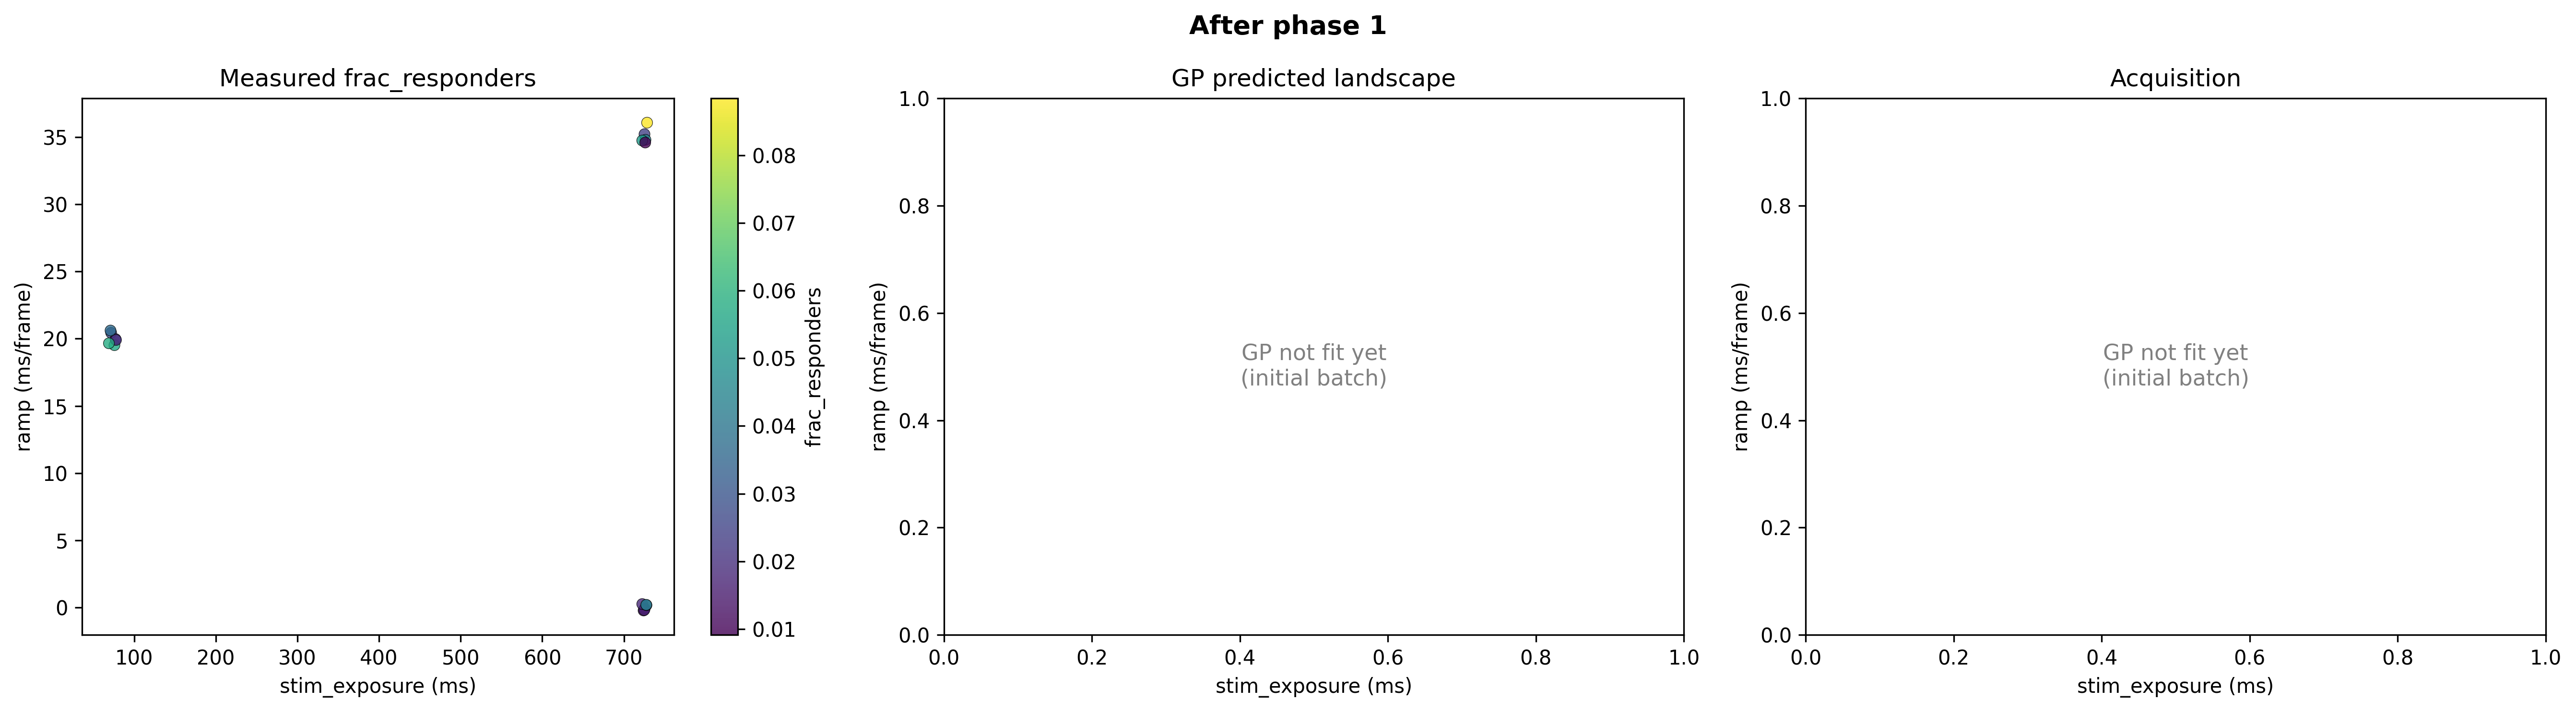


=== ComposedAgent: phase 2/12 ===
[FOVFinderAgent] Phase 1 — selected FOVs:
    A8_0000: 193 cells
    A8_0001: 172 cells
    A8_0002: 334 cells
    A9_0000: 191 cells
    A9_0001: 245 cells
    A9_0002: 233 cells
    A10_0000: 227 cells
    A10_0001: 203 cells
    A10_0002: 251 cells
    A11_0000: 247 cells
    A11_0001: 203 cells
    A11_0002: 143 cells
    A12_0000: 208 cells
    A12_0001: 239 cells
    A12_0002: 115 cells
    B12_0000: 169 cells
    B12_0001: 168 cells
    B12_0002: 124 cells
=== Phase 1: initial batch 2/2 ===
  Condition 0: {'stim_exposure': np.float32(275.0), 'ramp': np.float32(0.0)}
  Condition 1: {'stim_exposure': np.float32(325.0), 'ramp': np.float32(35.0)}
  Condition 2: {'stim_exposure': np.float32(500.0), 'ramp': np.float32(15.0)}
  Created 1620 events for phase 1
    Cond 0 (FOVs 18-23): stim_exposure=275ms, ramp=0ms/frame (final exposure: 275ms)
    Cond 1 (FOVs 24-29): stim_exposure=325ms, ramp=35ms/frame (final exposure: 2390ms)
    Cond 2 (FOVs 30-35)

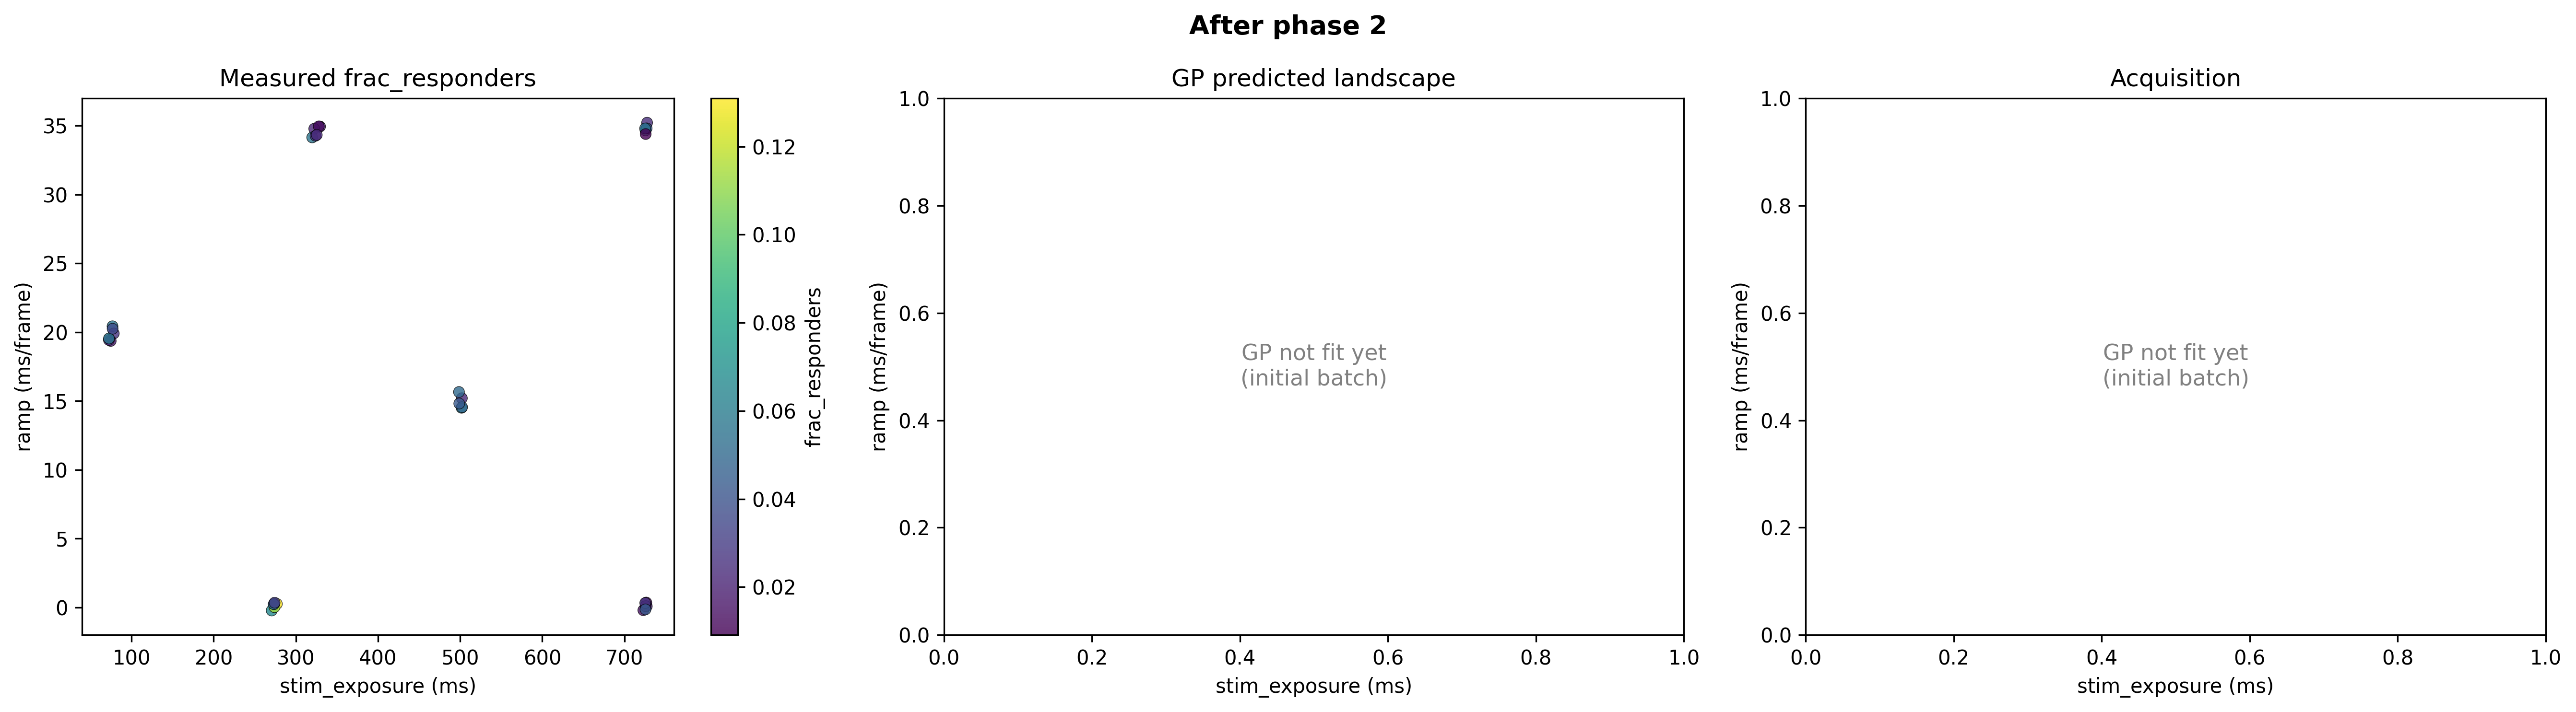


=== ComposedAgent: phase 3/12 ===
[FOVFinderAgent] Phase 2 — selected FOVs:
    B11_0000: 224 cells
    B11_0001: 306 cells
    B11_0002: 46 cells
    B10_0000: 276 cells
    B10_0001: 241 cells
    B10_0002: 210 cells
    B9_0000: 139 cells
    B9_0001: 323 cells
    B9_0002: 253 cells
    B8_0000: 127 cells
    B8_0001: 141 cells
    B8_0002: 127 cells
    B7_0000: 64 cells
    B7_0001: 141 cells
    B7_0002: 287 cells
    B6_0000: 168 cells
    B6_0001: 144 cells
    B6_0002: 189 cells


sample: 100%|##########| 1200/1200 [00:03<00:00, 366.71it/s, 7 steps of size 4.13e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      1.37      1.59      0.85      0.02      3.00    502.75      1.00
k_length[1]      1.53      1.79      0.97      0.07      3.36    672.36      1.00
k_length[2]      1.43      1.69      0.82      0.04      3.53    743.26      1.01
k_length[3]      1.43      1.72      0.87      0.06      3.25    694.55      1.00
k_length[4]      1.39      1.96      0.73      0.02      3.17    473.10      1.00
    k_scale      0.52      0.34      0.44      0.09      0.98    533.92      1.00
      noise      0.73      0.32      0.71      0.21      1.24    523.51      1.00

Computing robust acquisition over 17800 scenarios (445 grid points x 40 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.145027
  Robust acq stats: min=0.054448, max=0.161227
  [reusing cached GP fit from earlier in this batch]
Computing robust acquisition over 17760 scenarios (444 grid points x 40 covariate samp

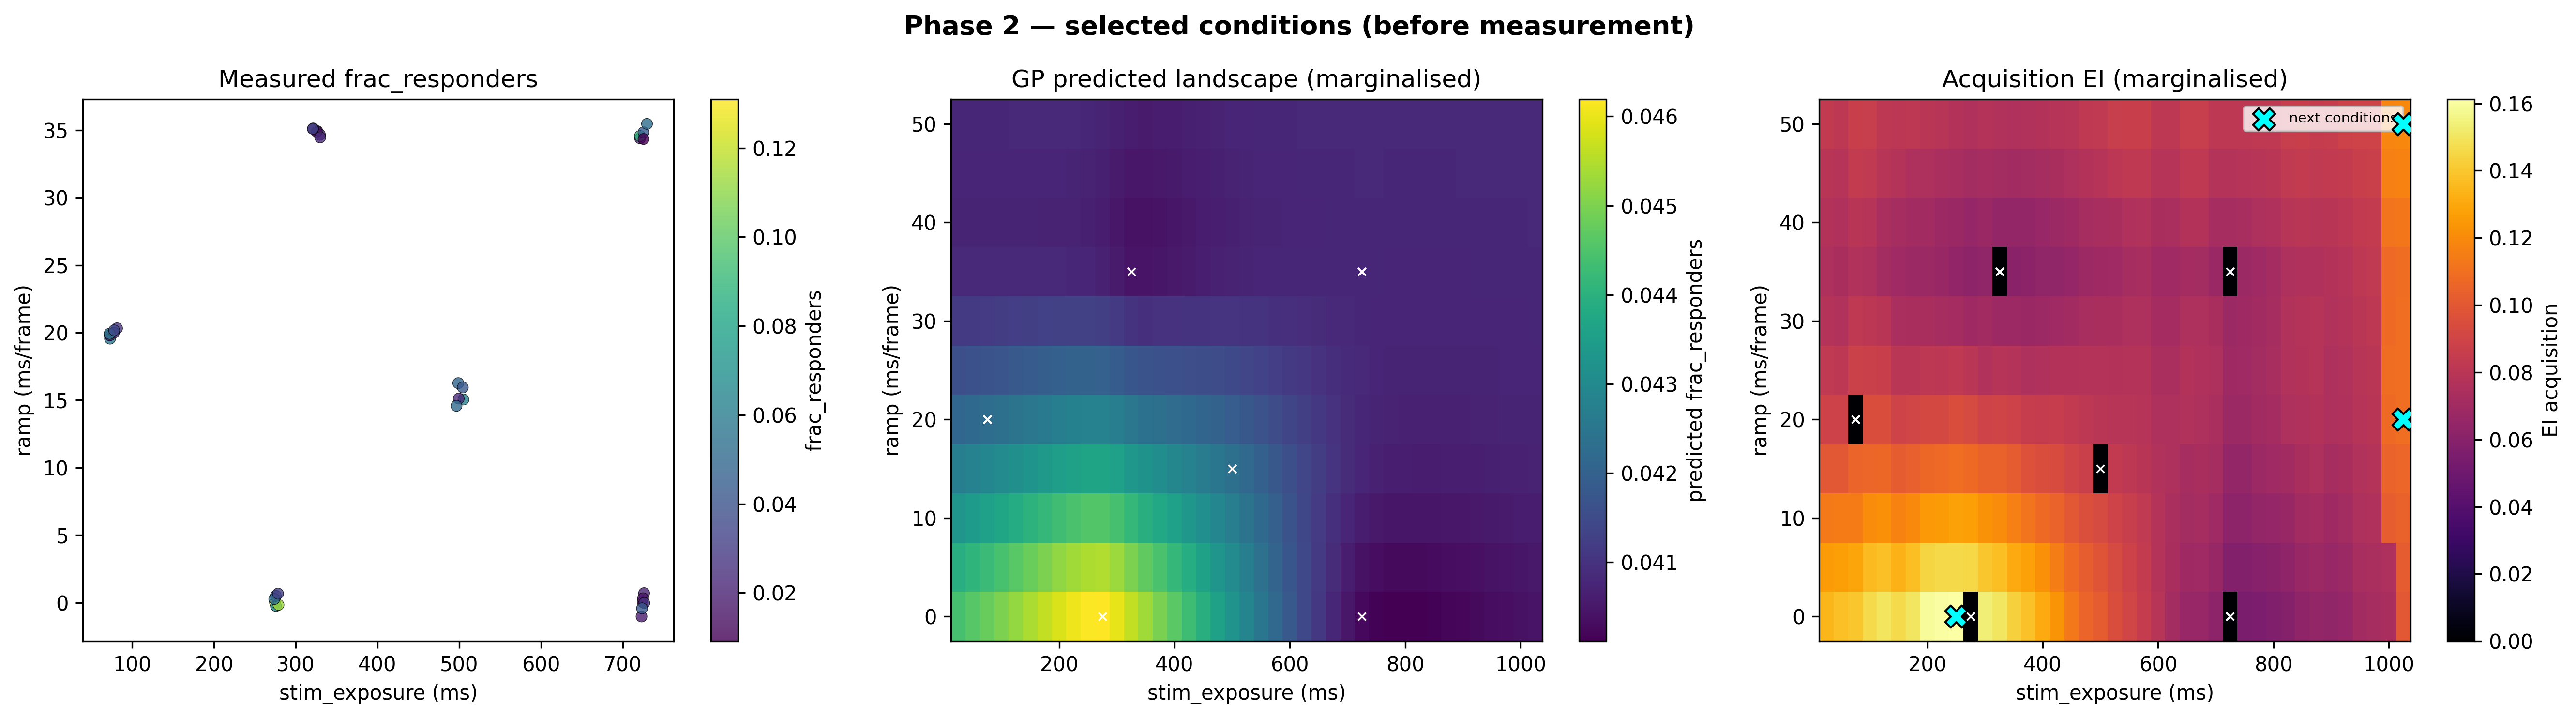

  Created 1620 events for phase 2
    Cond 0 (FOVs 36-41): stim_exposure=250ms, ramp=0ms/frame (final exposure: 250ms)
    Cond 1 (FOVs 42-47): stim_exposure=1025ms, ramp=50ms/frame (final exposure: 3975ms)
    Cond 2 (FOVs 48-53): stim_exposure=1025ms, ramp=20ms/frame (final exposure: 2205ms)
  Phase 2: 17 FOVs, mean frac_oscillating=1.0000, max=1.0000


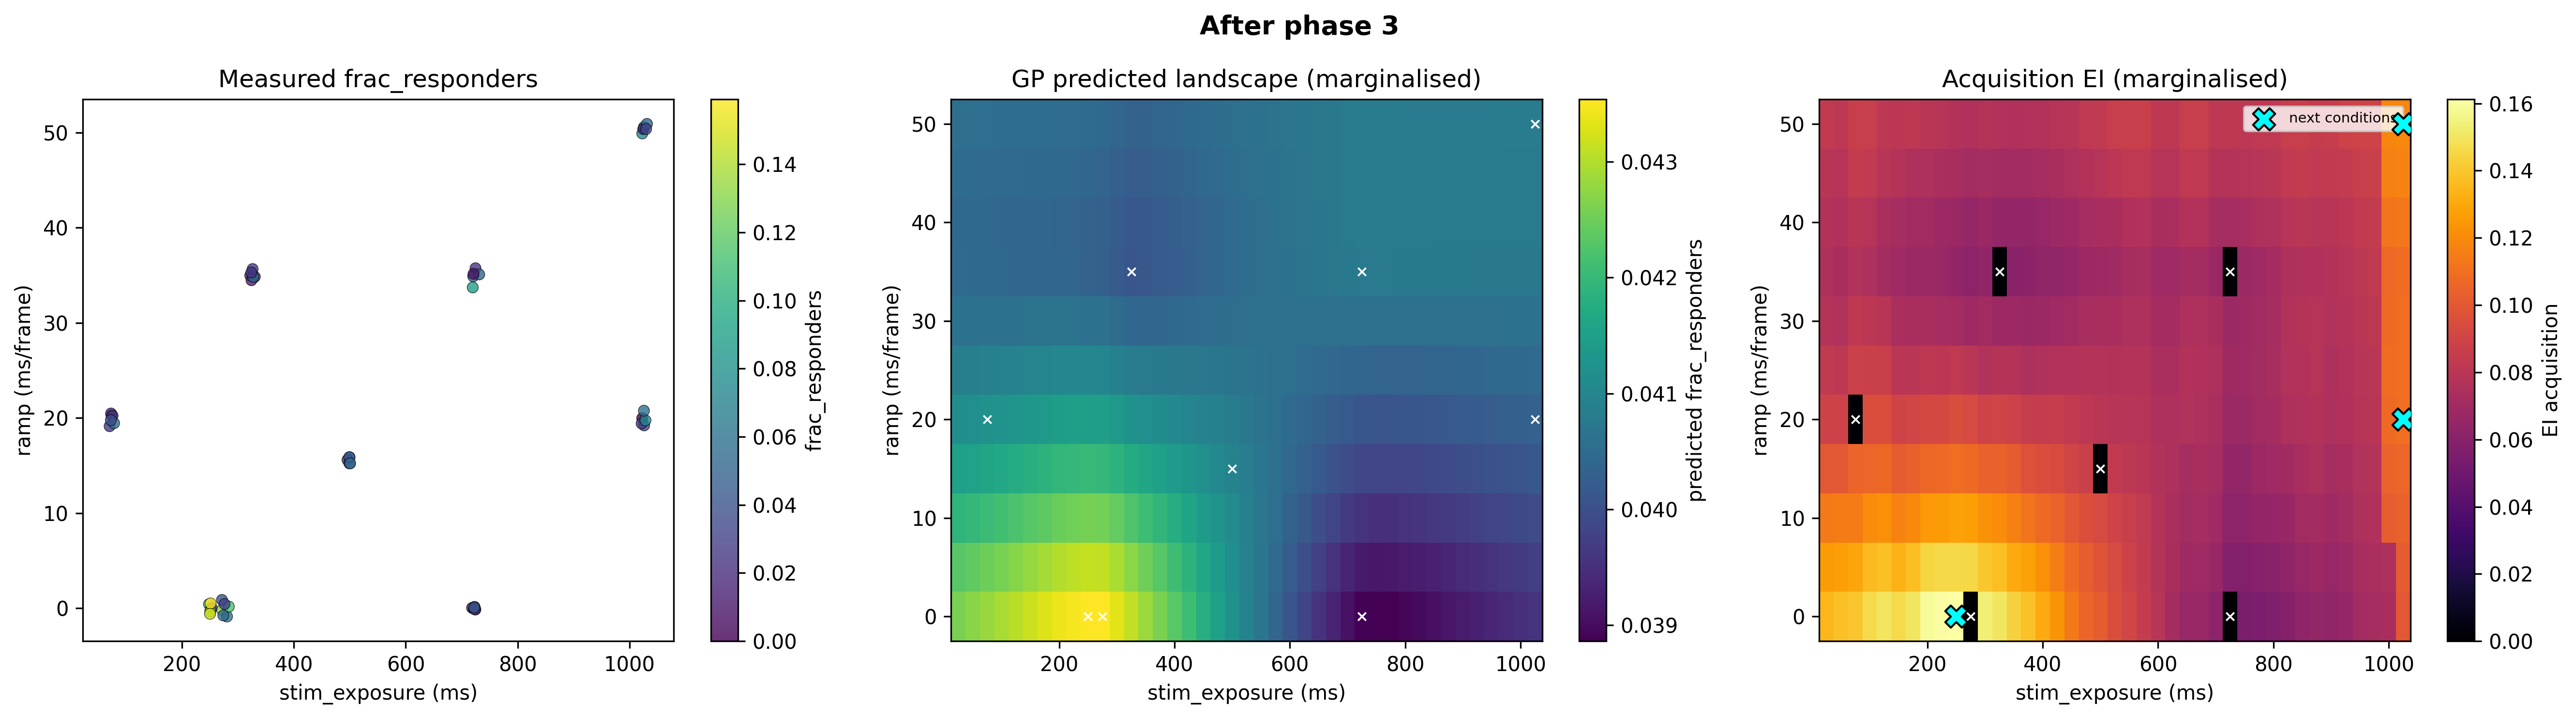


=== ComposedAgent: phase 4/12 ===
[FOVFinderAgent] Phase 3 — selected FOVs:
    B5_0000: 285 cells
    B5_0001: 150 cells
    B5_0002: 260 cells
    B4_0000: 234 cells
    B4_0001: 167 cells
    B4_0002: 240 cells
    B3_0000: 301 cells
    B3_0001: 130 cells
    B3_0002: 301 cells
    B2_0000: 242 cells
    B2_0001: 127 cells
    B2_0002: 239 cells
    C2_0000: 183 cells
    C2_0001: 206 cells
    C2_0002: 187 cells
    C3_0000: 198 cells
    C3_0001: 200 cells
    C3_0002: 158 cells


sample: 100%|##########| 1200/1200 [00:03<00:00, 323.68it/s, 7 steps of size 4.23e-01. acc. prob=0.90] 



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.35      0.69      0.18      0.03      0.75    548.61      1.00
k_length[1]      1.47      1.95      0.86      0.07      3.36    411.14      1.00
k_length[2]      2.49      2.02      2.00      0.40      4.94    714.25      1.00
k_length[3]      3.59      3.23      2.87      0.10      6.90    540.31      1.00
k_length[4]      2.37      2.98      1.49      0.12      5.13    323.02      1.00
    k_scale      0.61      0.30      0.56      0.17      1.05    365.70      1.00
      noise      0.48      0.19      0.46      0.12      0.75    296.53      1.00

Computing robust acquisition over 17680 scenarios (442 grid points x 40 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.745277
  Robust acq stats: min=0.004002, max=0.258262
  [reusing cached GP fit from earlier in this batch]
Computing robust acquisition over 17640 scenarios (441 grid points x 40 covariate samp

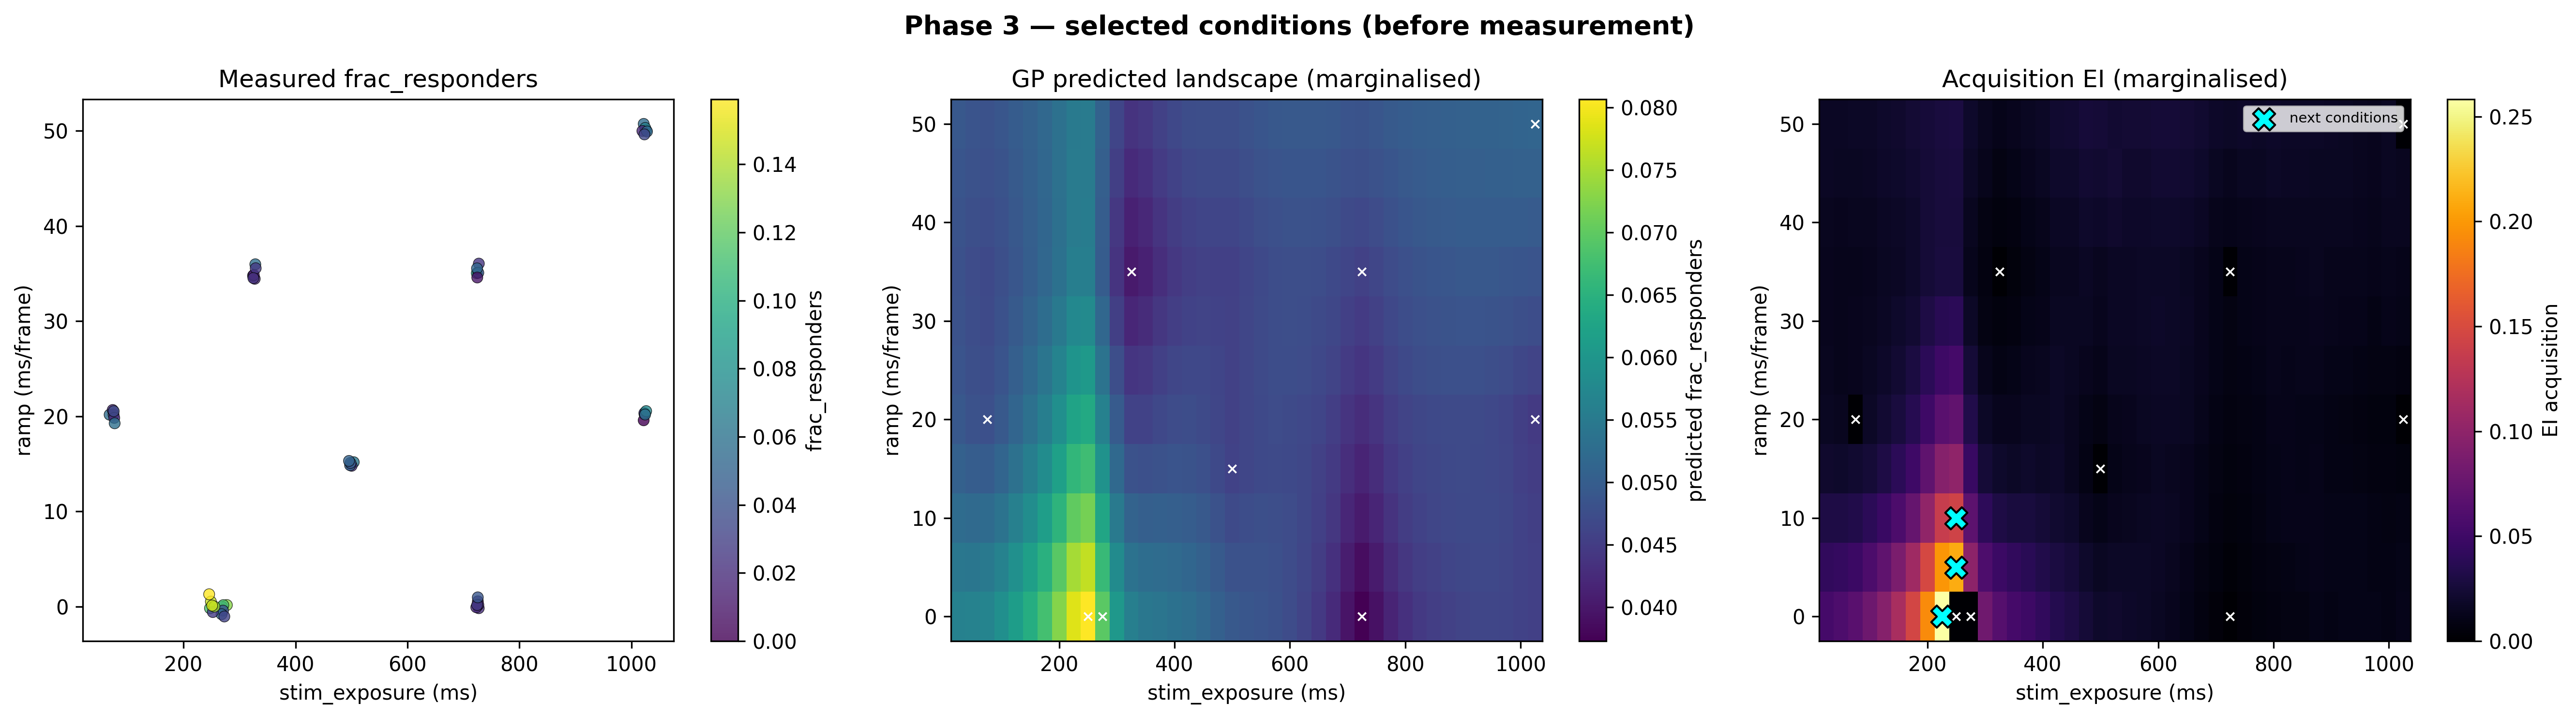

  Created 1620 events for phase 3
    Cond 0 (FOVs 54-59): stim_exposure=225ms, ramp=0ms/frame (final exposure: 225ms)
    Cond 1 (FOVs 60-65): stim_exposure=250ms, ramp=10ms/frame (final exposure: 840ms)
    Cond 2 (FOVs 66-71): stim_exposure=250ms, ramp=5ms/frame (final exposure: 545ms)
  Phase 3: 17 FOVs, mean frac_oscillating=0.9989, max=1.0000


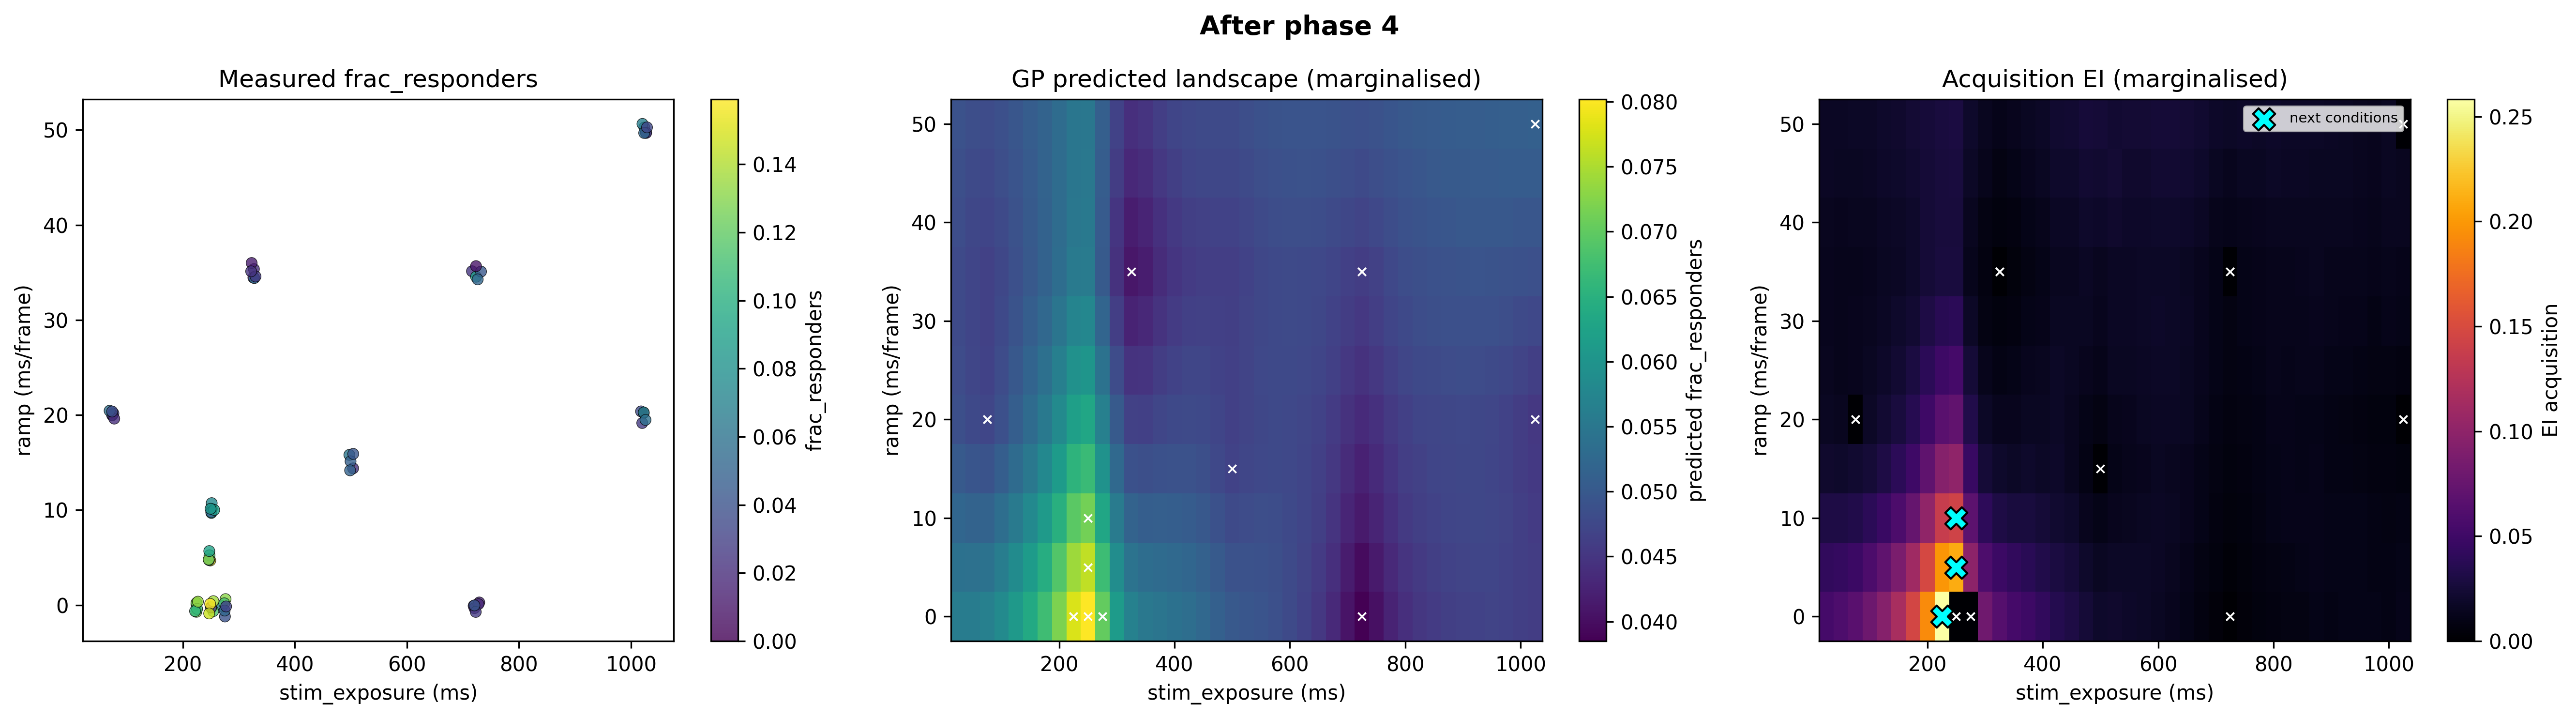


=== ComposedAgent: phase 5/12 ===
[FOVFinderAgent] Phase 4 — selected FOVs:
    C4_0000: 238 cells
    C4_0001: 255 cells
    C4_0002: 254 cells
    C5_0000: 264 cells
    C5_0001: 201 cells
    C5_0002: 290 cells
    C6_0000: 211 cells
    C6_0001: 280 cells
    C6_0002: 197 cells
    C7_0000: 135 cells
    C7_0001: 223 cells
    C7_0002: 163 cells
    C8_0000: 225 cells
    C8_0001: 264 cells
    C8_0002: 174 cells
    C9_0000: 247 cells
    C9_0001: 239 cells
    C9_0002: 285 cells


sample: 100%|##########| 1200/1200 [00:04<00:00, 280.84it/s, 7 steps of size 4.45e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.26      0.26      0.16      0.03      0.63    390.28      1.00
k_length[1]      1.22      1.40      0.80      0.11      2.56    437.45      1.00
k_length[2]      3.31      2.53      2.57      0.77      6.40    601.76      1.00
k_length[3]      4.45      3.77      3.58      0.43      8.57    875.51      1.00
k_length[4]      3.22      2.66      2.46      0.57      6.12    440.56      1.00
    k_scale      0.52      0.24      0.49      0.20      0.84    643.61      1.00
      noise      0.44      0.11      0.43      0.25      0.61    525.45      1.00

Computing robust acquisition over 17560 scenarios (439 grid points x 40 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.836665
  Robust acq stats: min=0.000192, max=0.148313
  [reusing cached GP fit from earlier in this batch]
Computing robust acquisition over 17520 scenarios (438 grid points x 40 covariate samp

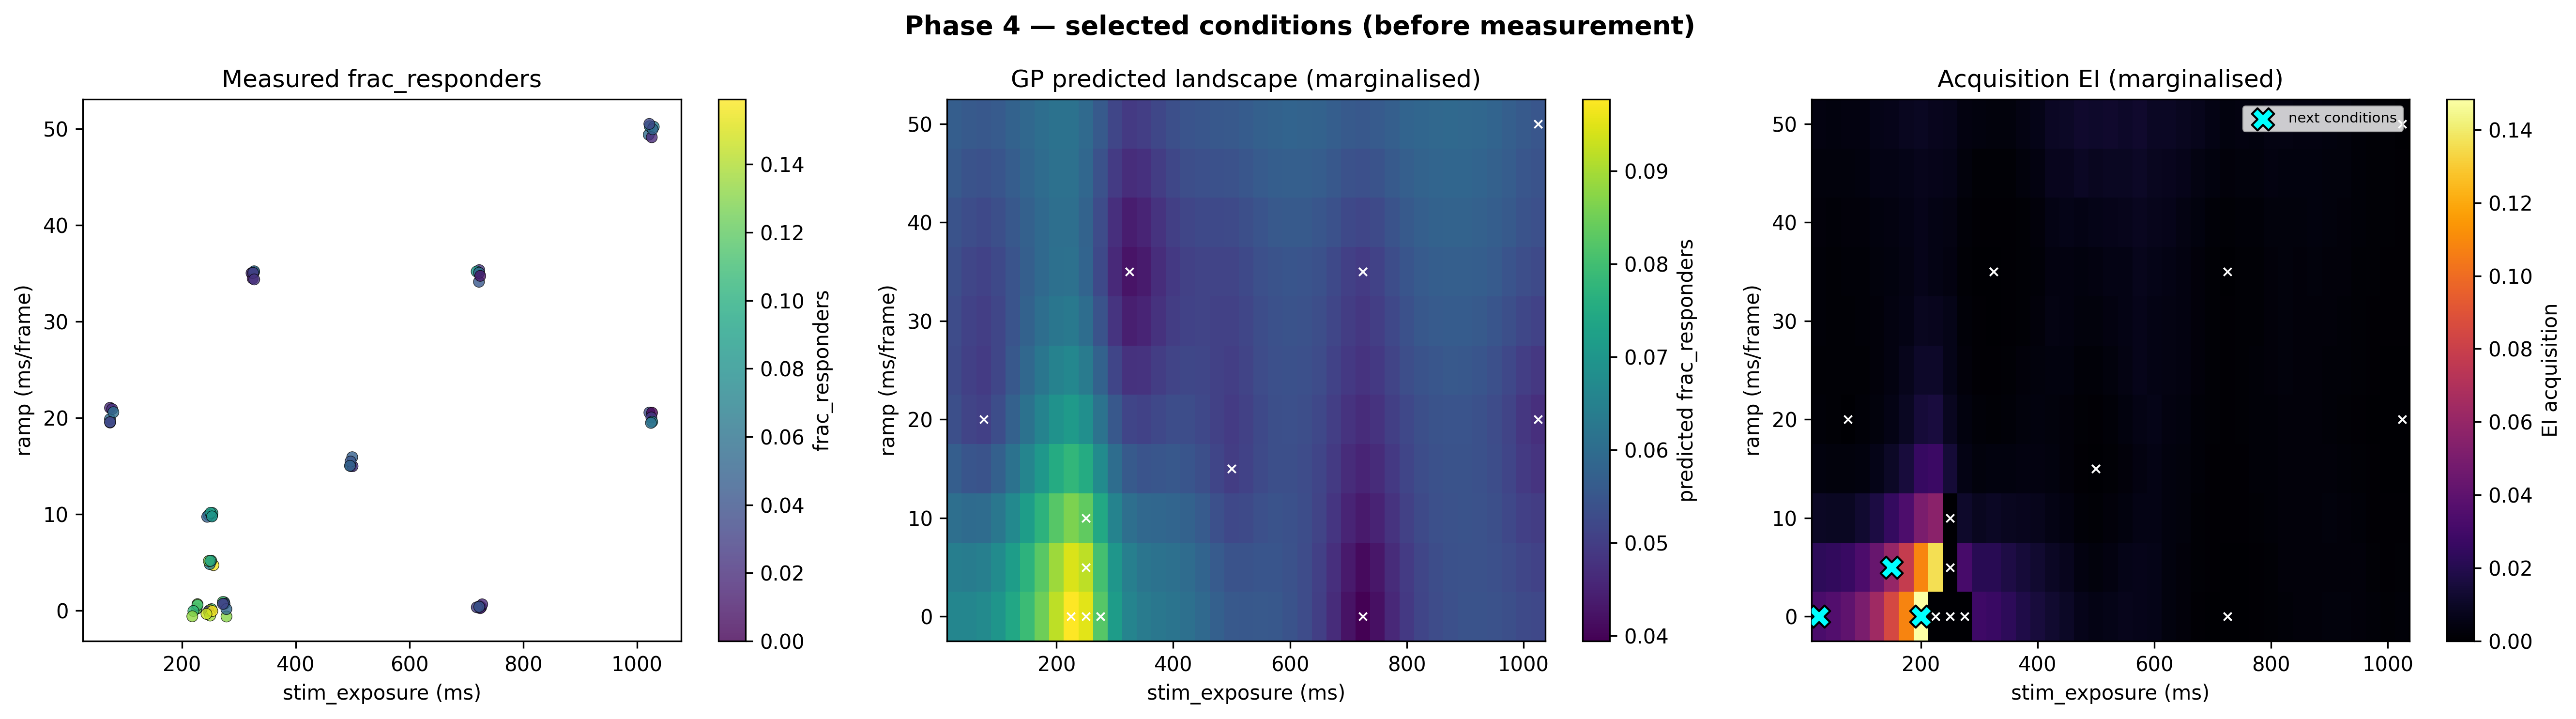

  Created 1620 events for phase 4
    Cond 0 (FOVs 72-77): stim_exposure=200ms, ramp=0ms/frame (final exposure: 200ms)
    Cond 1 (FOVs 78-83): stim_exposure=150ms, ramp=5ms/frame (final exposure: 445ms)
    Cond 2 (FOVs 84-89): stim_exposure=25ms, ramp=0ms/frame (final exposure: 25ms)
  Phase 4: 17 FOVs, mean frac_oscillating=0.9994, max=1.0000


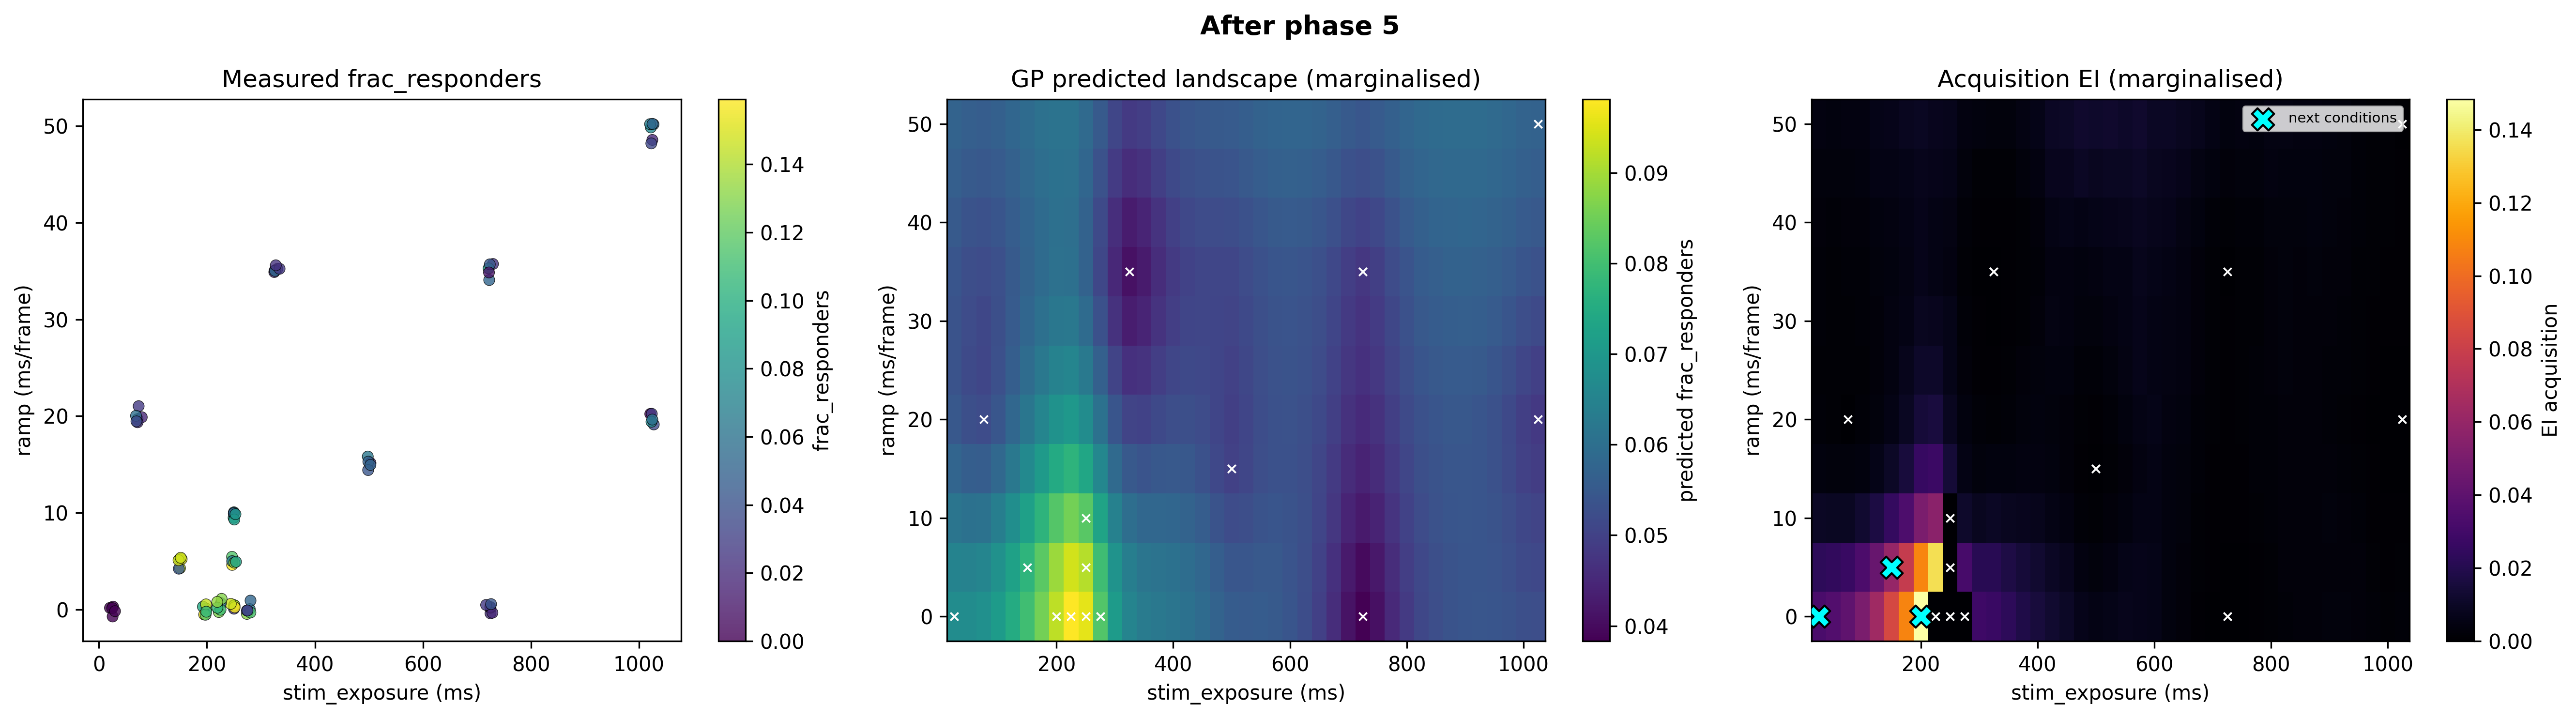


=== ComposedAgent: phase 6/12 ===
[FOVFinderAgent] Phase 5 — selected FOVs:
    C10_0000: 209 cells
    C10_0001: 175 cells
    C10_0002: 264 cells
    C11_0000: 223 cells
    C11_0001: 278 cells
    C11_0002: 258 cells
    C12_0000: 162 cells
    C12_0001: 345 cells
    C12_0002: 167 cells
    D12_0000: 187 cells
    D12_0001: 316 cells
    D12_0002: 124 cells
    D11_0000: 124 cells
    D11_0001: 309 cells
    D11_0002: 187 cells
    D10_0000: 274 cells
    D10_0001: 209 cells
    D10_0002: 325 cells


sample: 100%|##########| 1200/1200 [00:04<00:00, 271.37it/s, 7 steps of size 5.53e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.16      0.06      0.16      0.07      0.25    793.42      1.00
k_length[1]      2.43      2.23      1.76      0.20      5.09    521.91      1.00
k_length[2]      2.85      1.89      2.31      0.93      5.18    435.38      1.01
k_length[3]      7.04      4.79      5.84      1.41     12.64    848.57      1.00
k_length[4]      4.62      3.26      3.78      1.27      8.59    446.19      1.00
    k_scale      0.65      0.27      0.60      0.29      1.06    784.42      1.00
      noise      0.33      0.07      0.32      0.22      0.44    811.83      1.00

Computing robust acquisition over 17440 scenarios (436 grid points x 40 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 1.141962
  Robust acq stats: min=0.000000, max=0.100122
  [reusing cached GP fit from earlier in this batch]
Computing robust acquisition over 17400 scenarios (435 grid points x 40 covariate samp

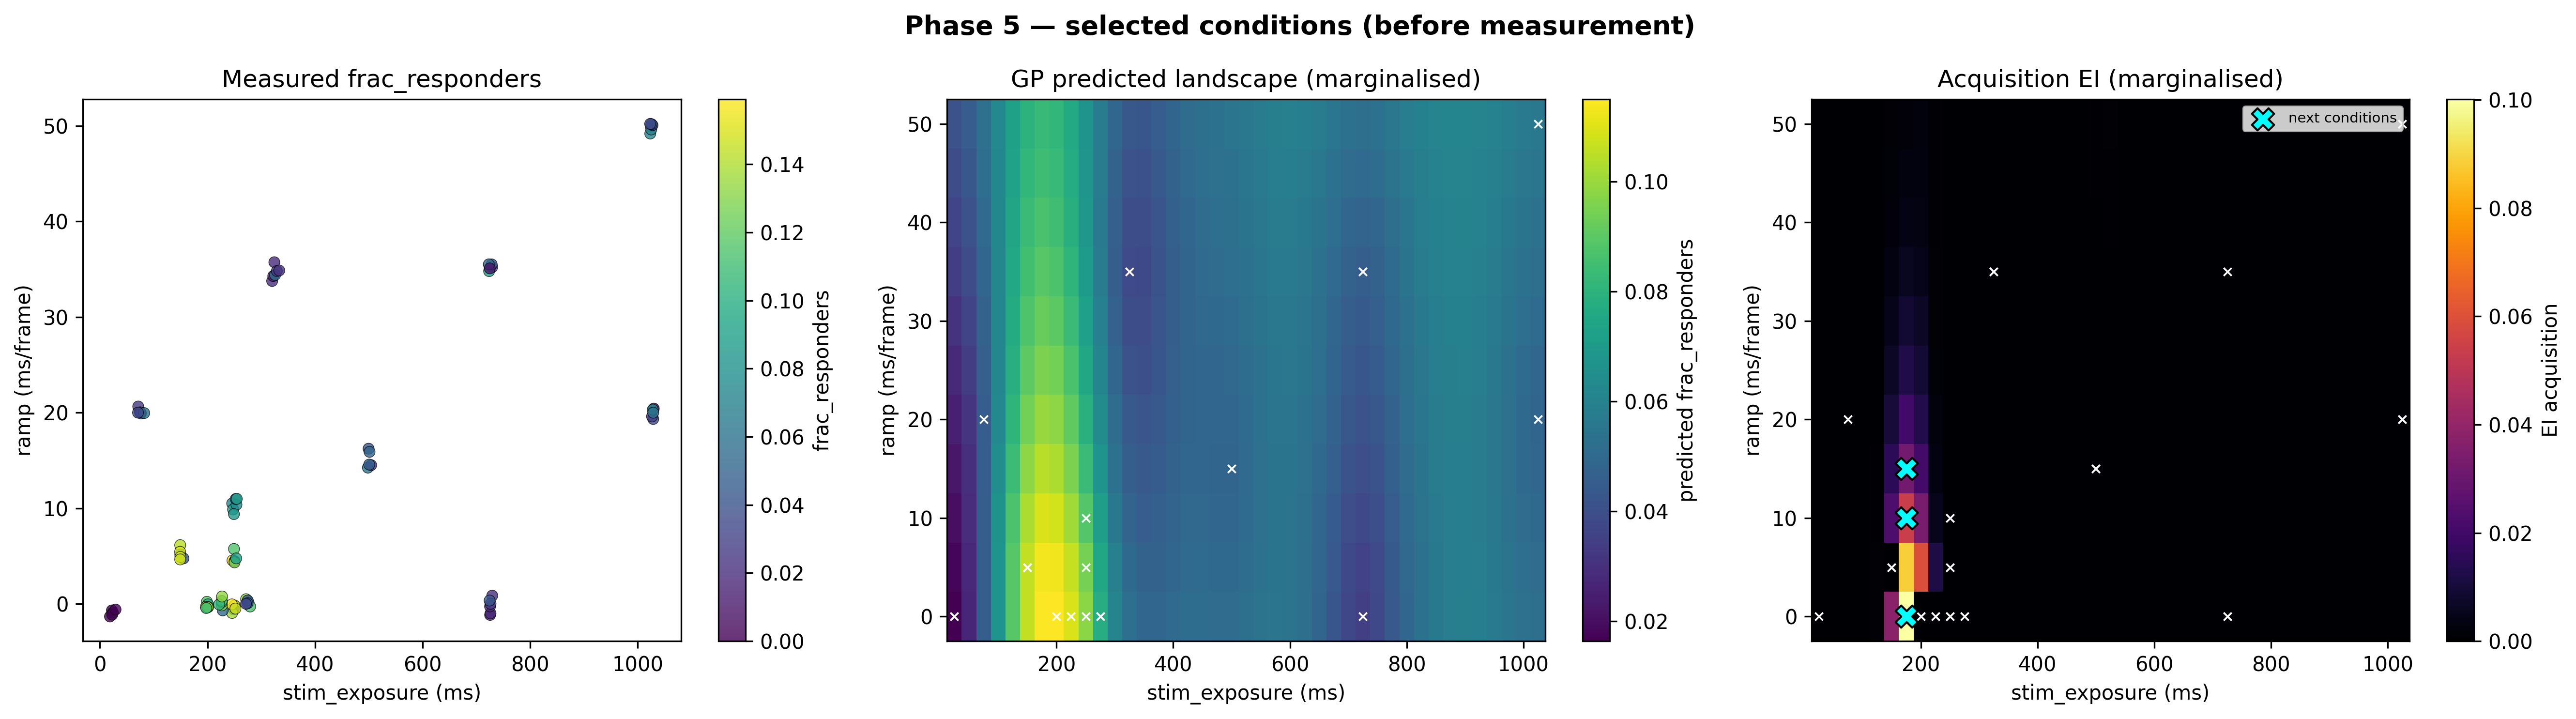

  Created 1620 events for phase 5
    Cond 0 (FOVs 90-95): stim_exposure=175ms, ramp=0ms/frame (final exposure: 175ms)
    Cond 1 (FOVs 96-101): stim_exposure=175ms, ramp=15ms/frame (final exposure: 1060ms)
    Cond 2 (FOVs 102-107): stim_exposure=175ms, ramp=10ms/frame (final exposure: 765ms)
  Phase 5: 17 FOVs, mean frac_oscillating=0.9991, max=1.0000


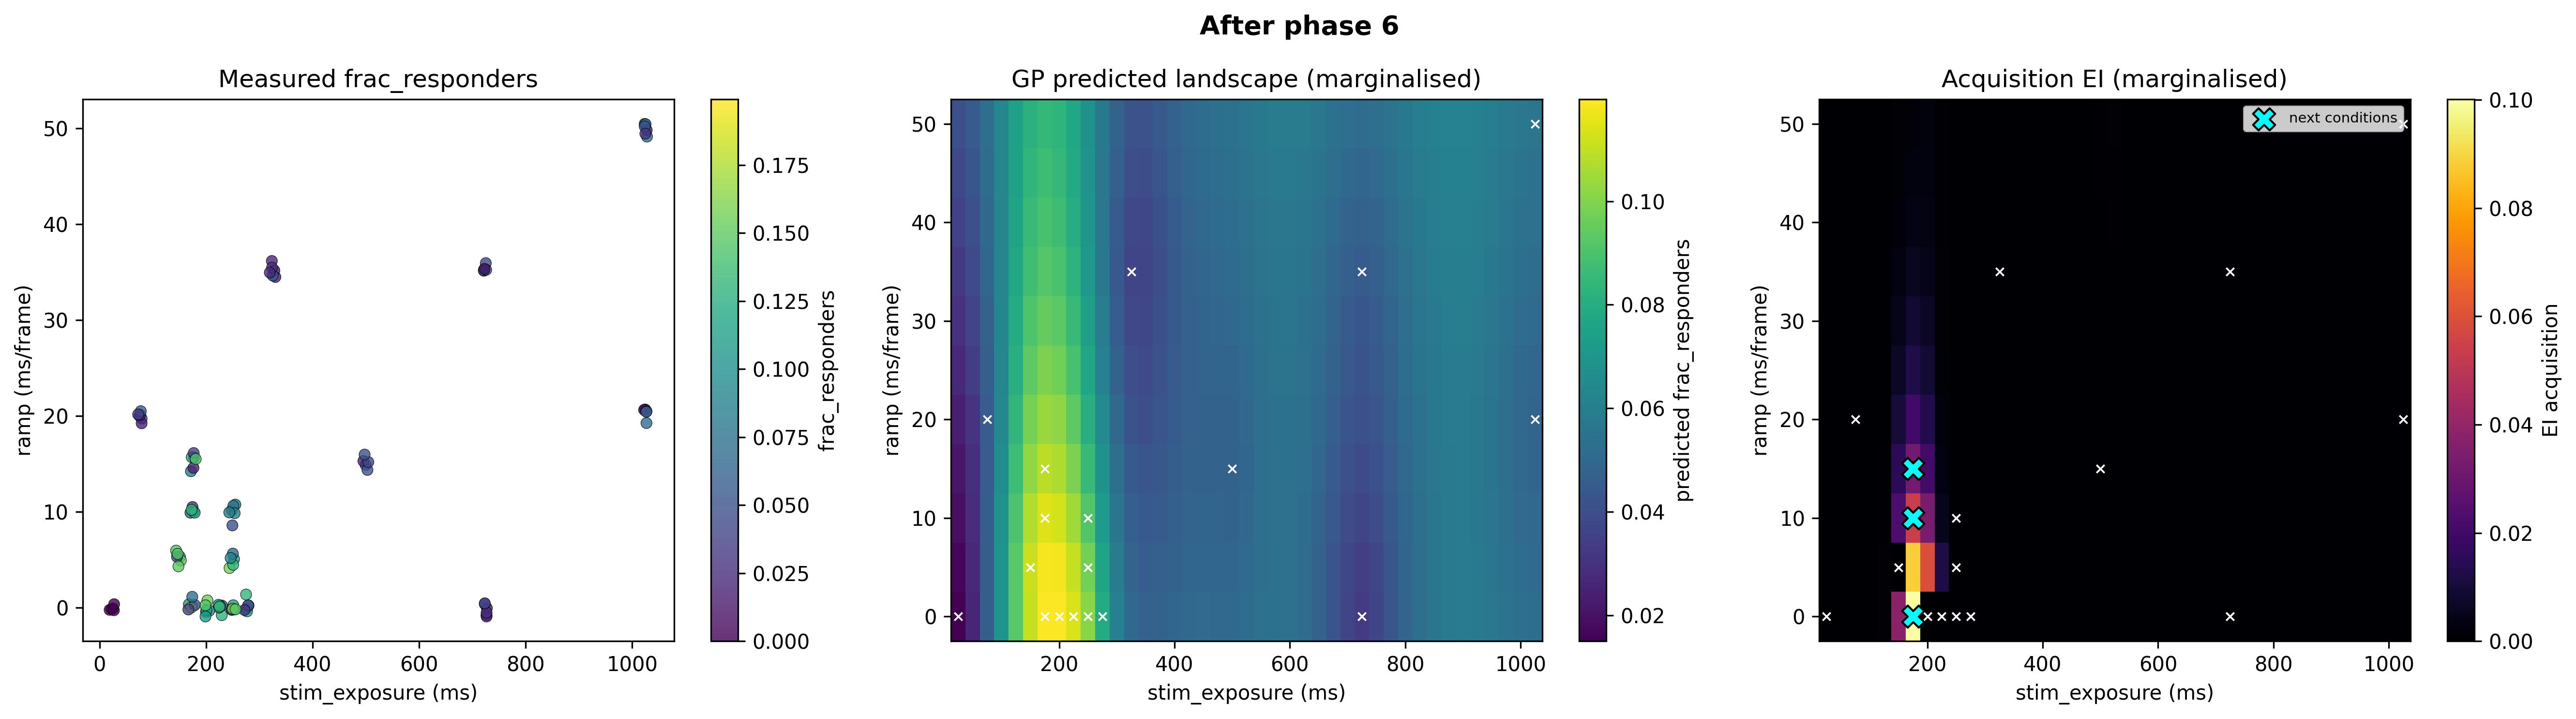


=== ComposedAgent: phase 7/12 ===
[FOVFinderAgent] Phase 6 — selected FOVs:
    D9_0000: 153 cells
    D9_0001: 299 cells
    D9_0002: 204 cells
    D8_0000: 148 cells
    D8_0001: 212 cells
    D8_0002: 144 cells
    D7_0000: 182 cells
    D7_0001: 246 cells
    D7_0002: 184 cells
    D6_0000: 180 cells
    D6_0001: 178 cells
    D6_0002: 126 cells
    D5_0000: 187 cells
    D5_0001: 132 cells
    D5_0002: 251 cells
    D4_0000: 175 cells
    D4_0001: 236 cells
    D4_0002: 152 cells


sample: 100%|##########| 1200/1200 [00:05<00:00, 204.28it/s, 7 steps of size 5.88e-01. acc. prob=0.89]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.19      0.08      0.17      0.06      0.30    641.46      1.00
k_length[1]      1.27      1.85      0.77      0.05      2.72    627.62      1.00
k_length[2]      3.10      2.12      2.56      0.81      5.49    705.33      1.00
k_length[3]      6.16      4.59      4.92      0.87     11.40    753.69      1.01
k_length[4]      4.79      3.95      3.57      0.88      9.01    453.29      1.00
    k_scale      0.58      0.26      0.53      0.20      0.89    704.71      1.00
      noise      0.47      0.09      0.46      0.34      0.62    865.13      1.00

Computing robust acquisition over 17320 scenarios (433 grid points x 40 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.741820
  Robust acq stats: min=0.000008, max=0.125139
  [reusing cached GP fit from earlier in this batch]
Computing robust acquisition over 17280 scenarios (432 grid points x 40 covariate samp

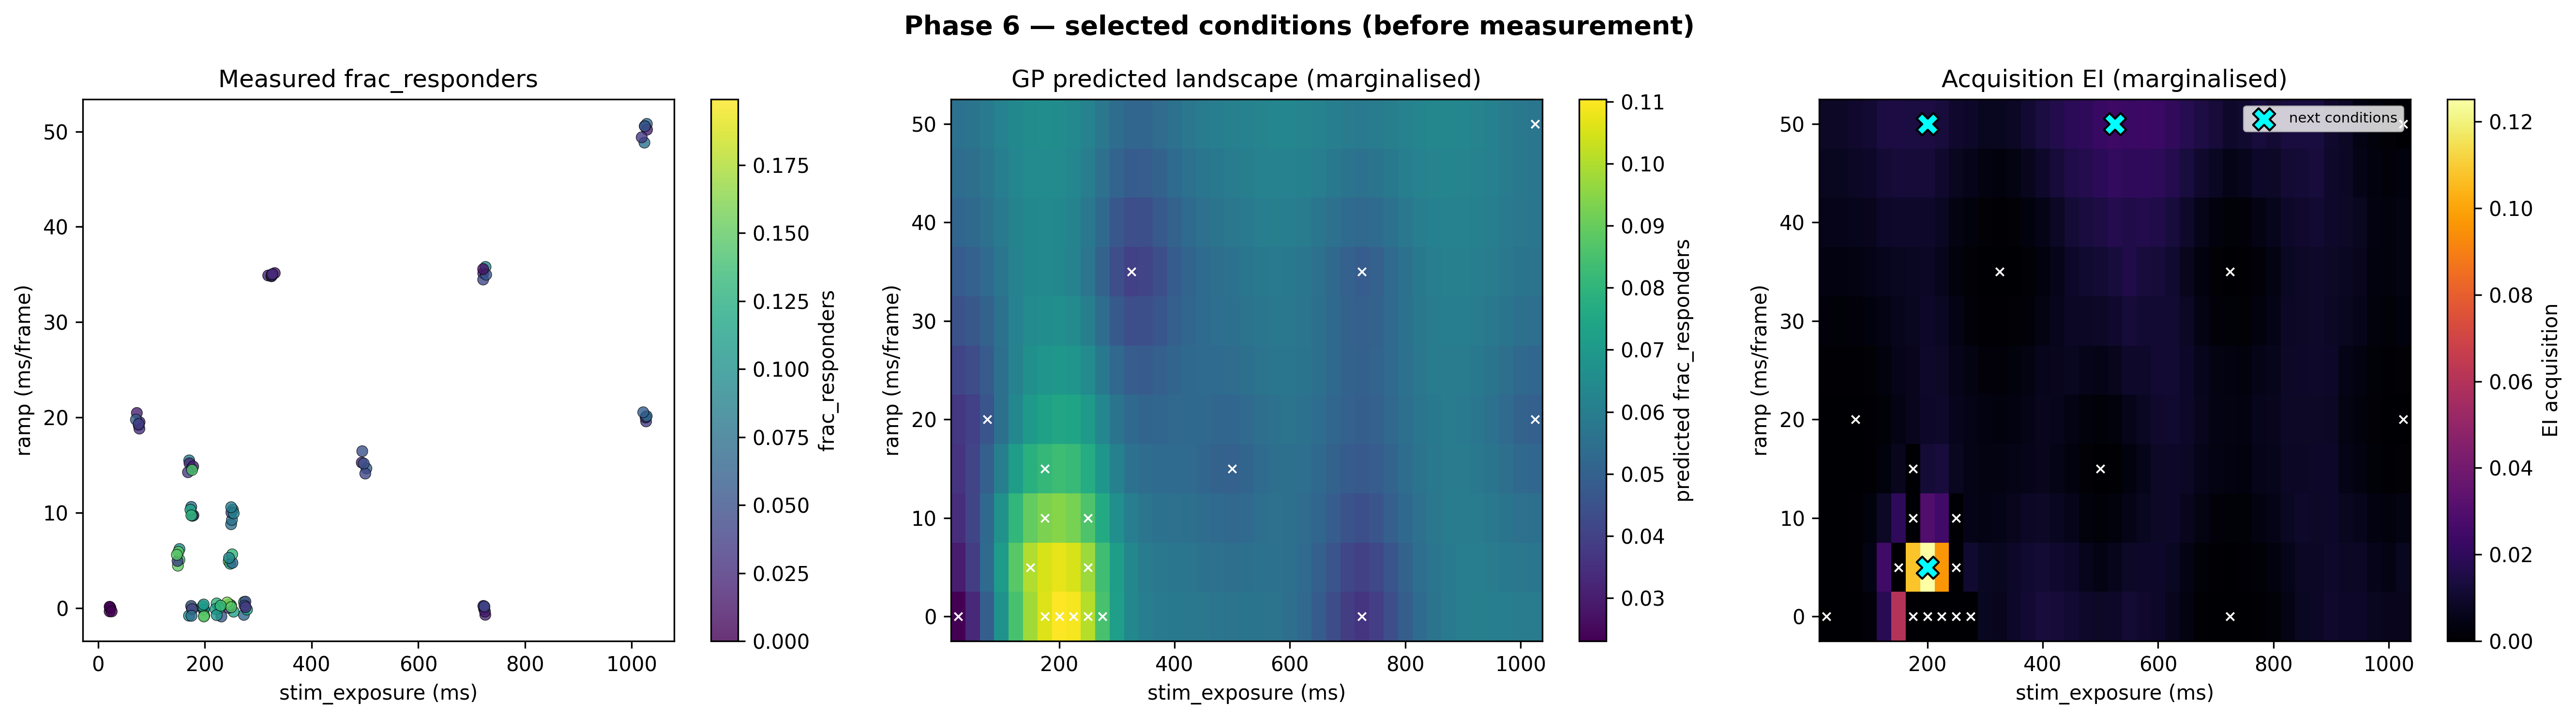

  Created 1620 events for phase 6
    Cond 0 (FOVs 108-113): stim_exposure=200ms, ramp=5ms/frame (final exposure: 495ms)
    Cond 1 (FOVs 114-119): stim_exposure=525ms, ramp=50ms/frame (final exposure: 3475ms)
    Cond 2 (FOVs 120-125): stim_exposure=200ms, ramp=50ms/frame (final exposure: 3150ms)
  Phase 6: 17 FOVs, mean frac_oscillating=0.9989, max=1.0000


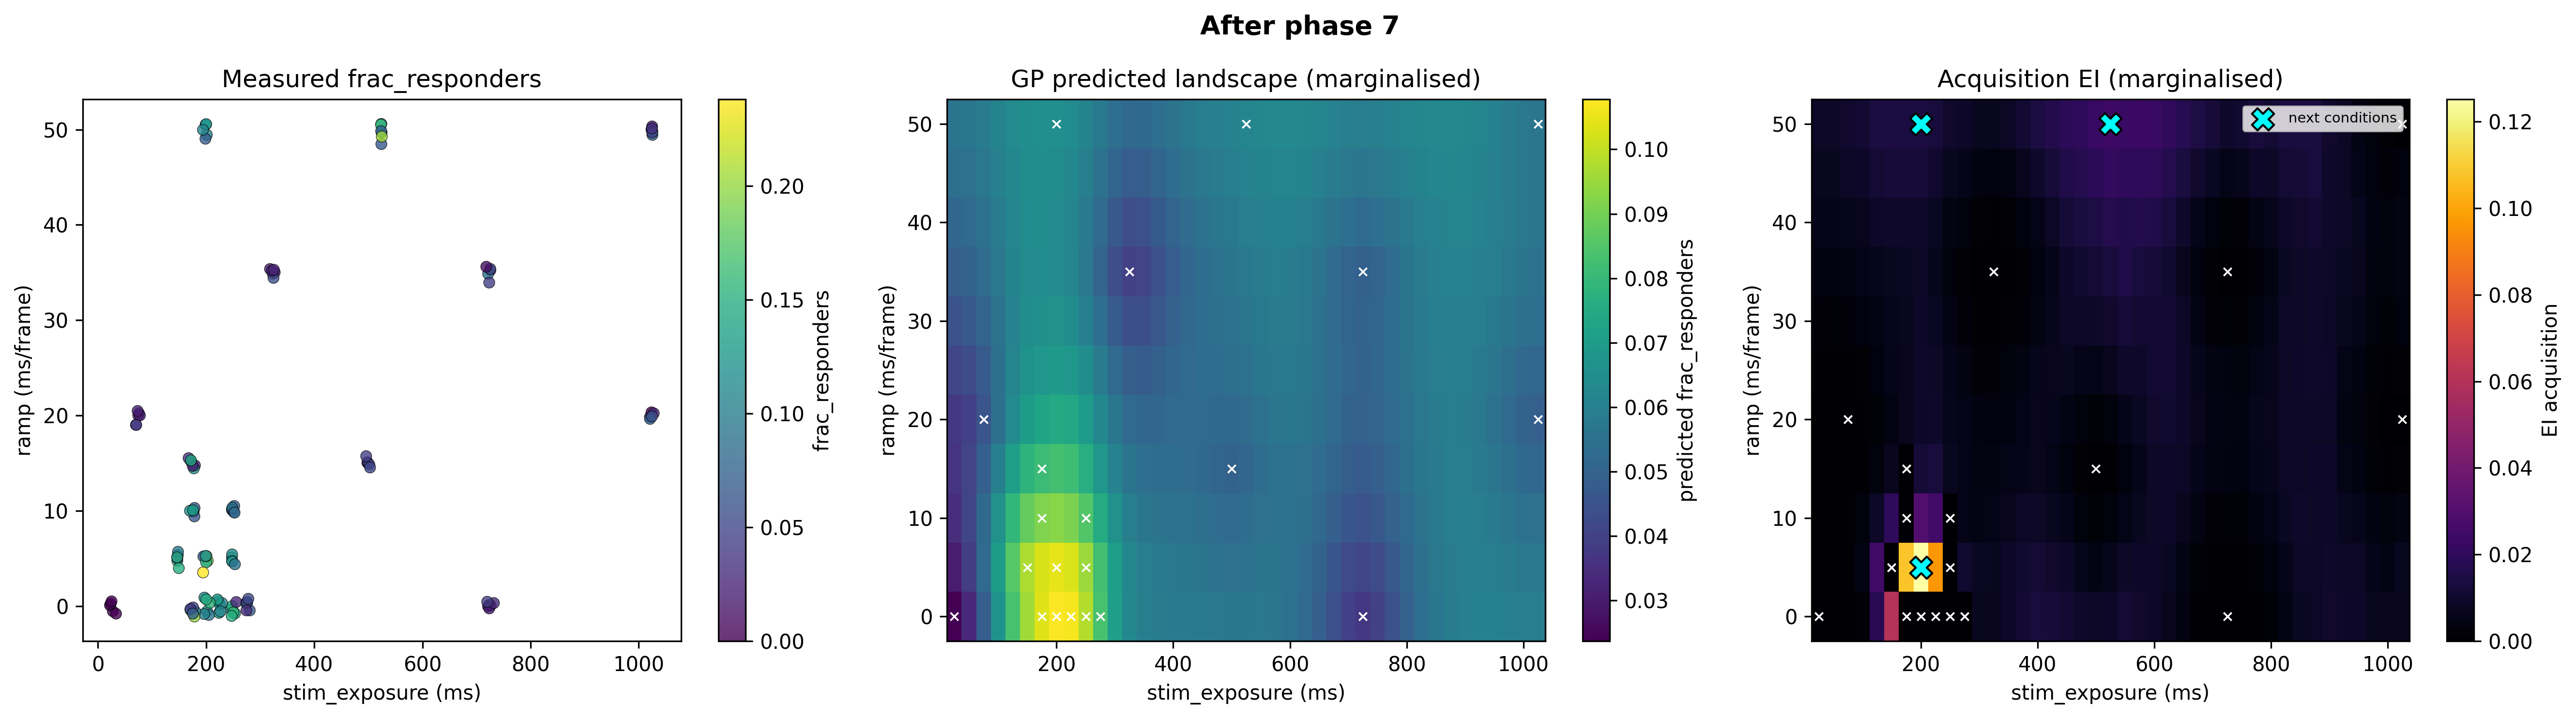


=== ComposedAgent: phase 8/12 ===
[FOVFinderAgent] Phase 7 — selected FOVs:
    D3_0000: 158 cells
    D3_0001: 251 cells
    D3_0002: 153 cells
    D2_0000: 219 cells
    D2_0001: 191 cells
    D2_0002: 225 cells
    A2_0000: 348 cells
    A2_0001: 156 cells
    A2_0002: 150 cells
    A3_0000: 283 cells
    A3_0001: 225 cells
    A3_0002: 237 cells
    A4_0000: 224 cells
    A4_0001: 246 cells
    A4_0002: 219 cells
    A5_0000: 279 cells
    A5_0001: 330 cells
    A5_0002: 204 cells


sample: 100%|##########| 1200/1200 [00:07<00:00, 158.14it/s, 7 steps of size 6.15e-01. acc. prob=0.88]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.12      0.07      0.11      0.03      0.21    682.53      1.00
k_length[1]      1.01      1.33      0.54      0.05      2.42    538.84      1.00
k_length[2]      3.21      1.96      2.77      0.98      5.35    480.66      1.00
k_length[3]      5.60      4.19      4.53      1.23     10.36    855.07      1.00
k_length[4]      5.76      4.08      4.68      1.63     10.11    569.45      1.00
    k_scale      0.66      0.25      0.62      0.32      1.05    708.01      1.00
      noise      0.42      0.08      0.41      0.30      0.55    797.65      1.00

Computing robust acquisition over 17200 scenarios (430 grid points x 40 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.834273
  Robust acq stats: min=0.000000, max=0.120142
  [reusing cached GP fit from earlier in this batch]
Computing robust acquisition over 17160 scenarios (429 grid points x 40 covariate samp

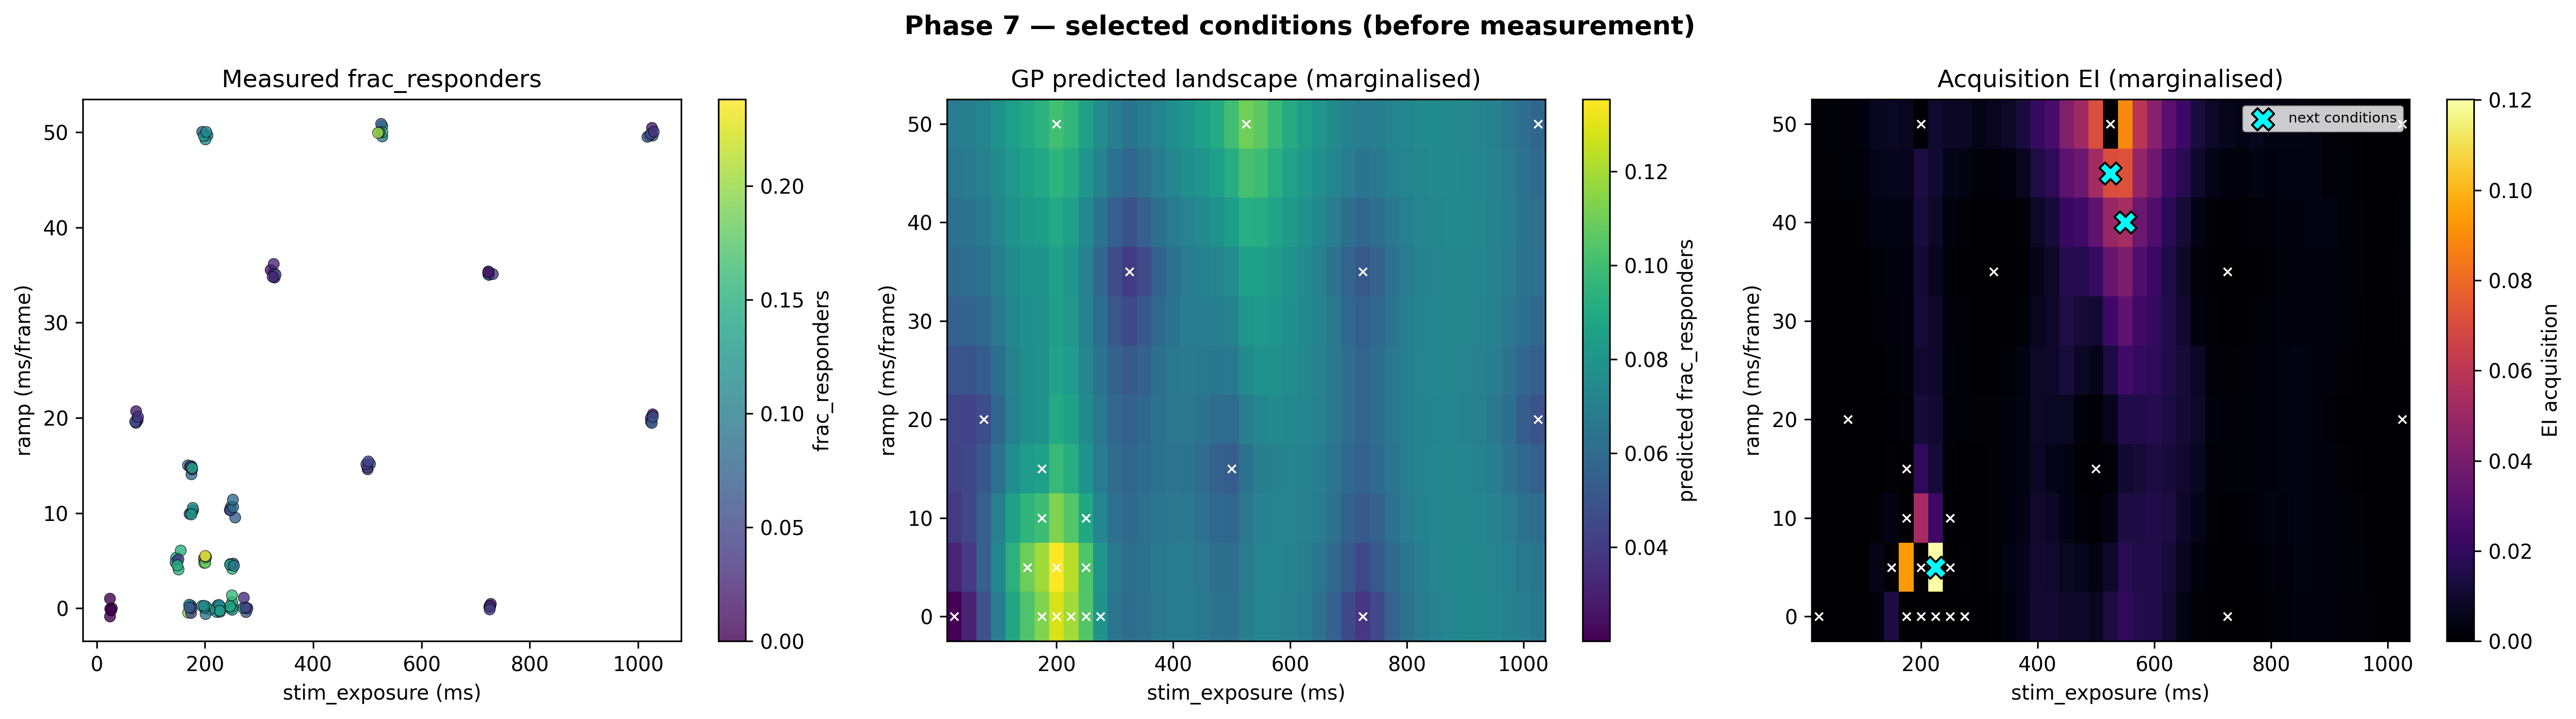

  Created 1620 events for phase 7
    Cond 0 (FOVs 126-131): stim_exposure=225ms, ramp=5ms/frame (final exposure: 520ms)
    Cond 1 (FOVs 132-137): stim_exposure=550ms, ramp=40ms/frame (final exposure: 2910ms)
    Cond 2 (FOVs 138-143): stim_exposure=525ms, ramp=45ms/frame (final exposure: 3180ms)
  Phase 7: 17 FOVs, mean frac_oscillating=0.9994, max=1.0000


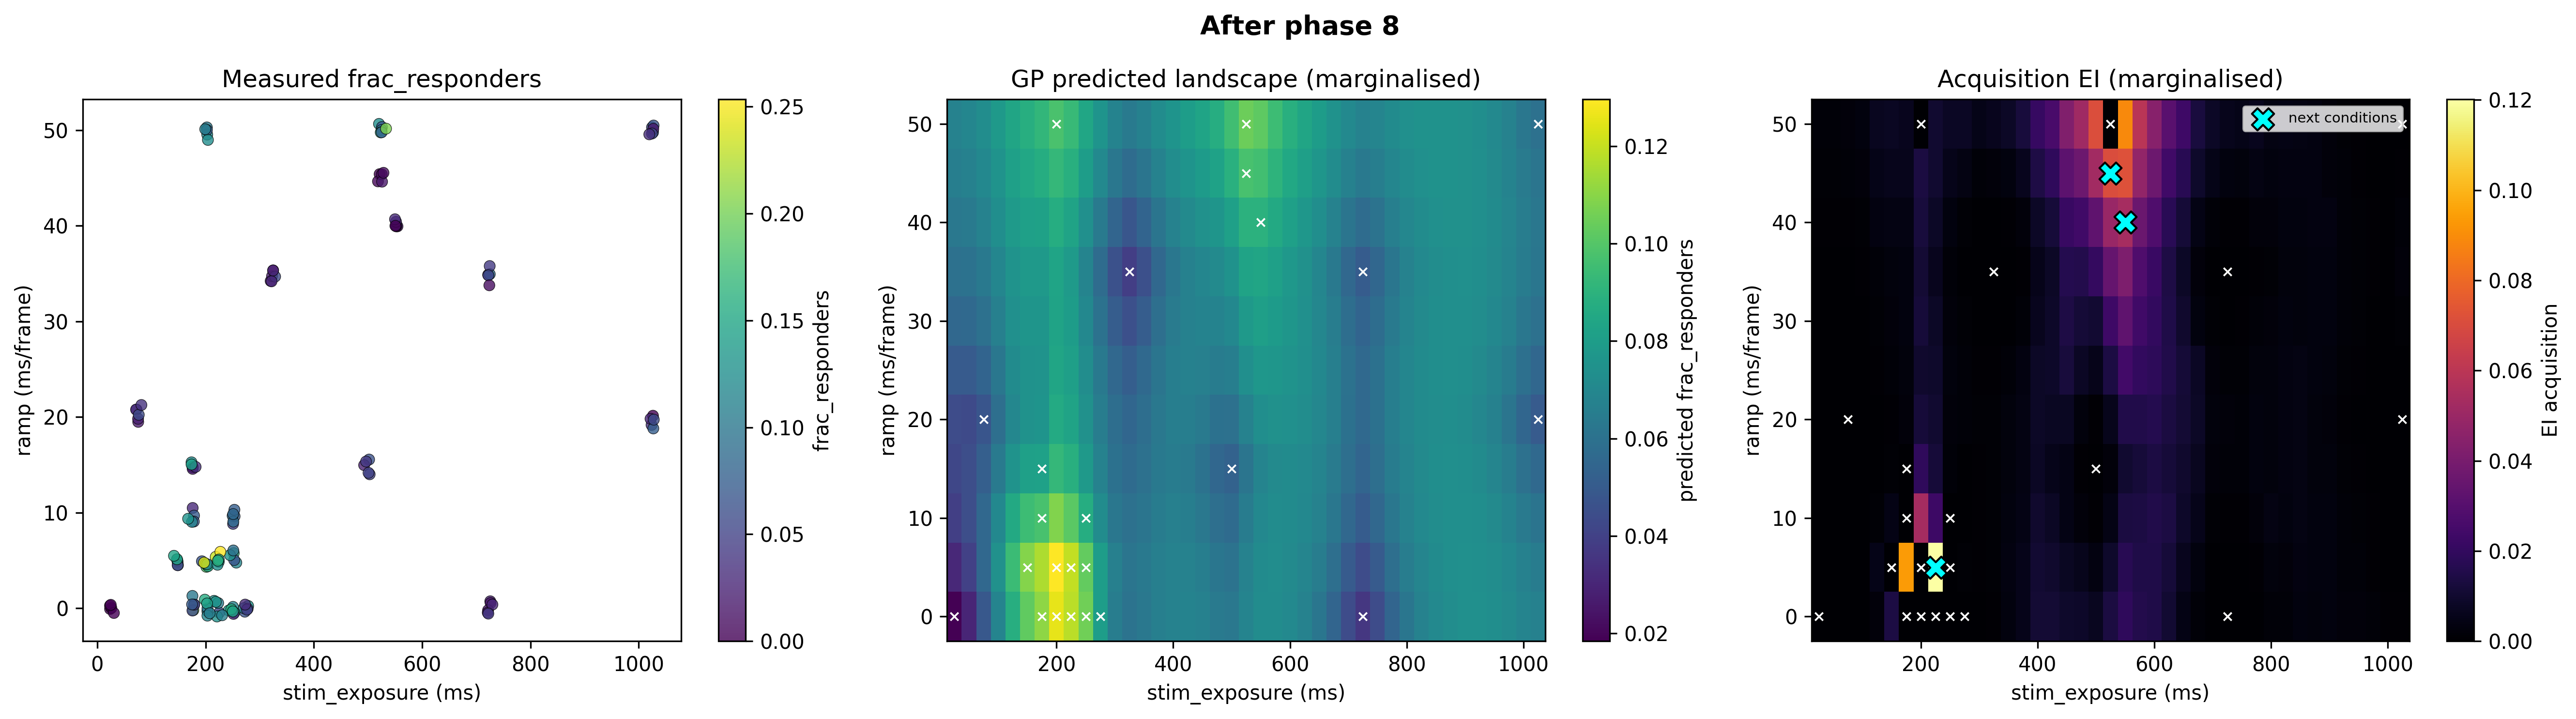


=== ComposedAgent: phase 9/12 ===
[FOVFinderAgent] Phase 8 — selected FOVs:
    A6_0000: 210 cells
    A6_0001: 319 cells
    A6_0002: 173 cells
    A7_0000: 215 cells
    A7_0001: 290 cells
    A7_0002: 300 cells
    A8_0000: 269 cells
    A8_0001: 160 cells
    A8_0002: 225 cells
    A9_0000: 247 cells
    A9_0001: 198 cells
    A9_0002: 229 cells
    A10_0000: 170 cells
    A10_0001: 267 cells
    A10_0002: 257 cells
    A11_0000: 277 cells
    A11_0001: 184 cells
    A11_0002: 190 cells


sample: 100%|##########| 1200/1200 [00:08<00:00, 143.24it/s, 7 steps of size 5.91e-01. acc. prob=0.88]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.11      0.05      0.10      0.04      0.19    962.82      1.00
k_length[1]      0.18      0.12      0.16      0.04      0.28    389.93      1.00
k_length[2]      3.04      1.49      2.68      1.17      4.88    521.30      1.00
k_length[3]      8.66      5.03      7.13      2.40     15.13    999.17      1.00
k_length[4]      6.24      3.90      5.18      1.92     10.75    587.59      1.00
    k_scale      0.64      0.20      0.61      0.35      0.94    645.31      1.00
      noise      0.31      0.05      0.31      0.23      0.40    783.90      1.00

Computing robust acquisition over 17080 scenarios (427 grid points x 40 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.879970
  Robust acq stats: min=0.000000, max=0.148941
  [reusing cached GP fit from earlier in this batch]
Computing robust acquisition over 17040 scenarios (426 grid points x 40 covariate samp

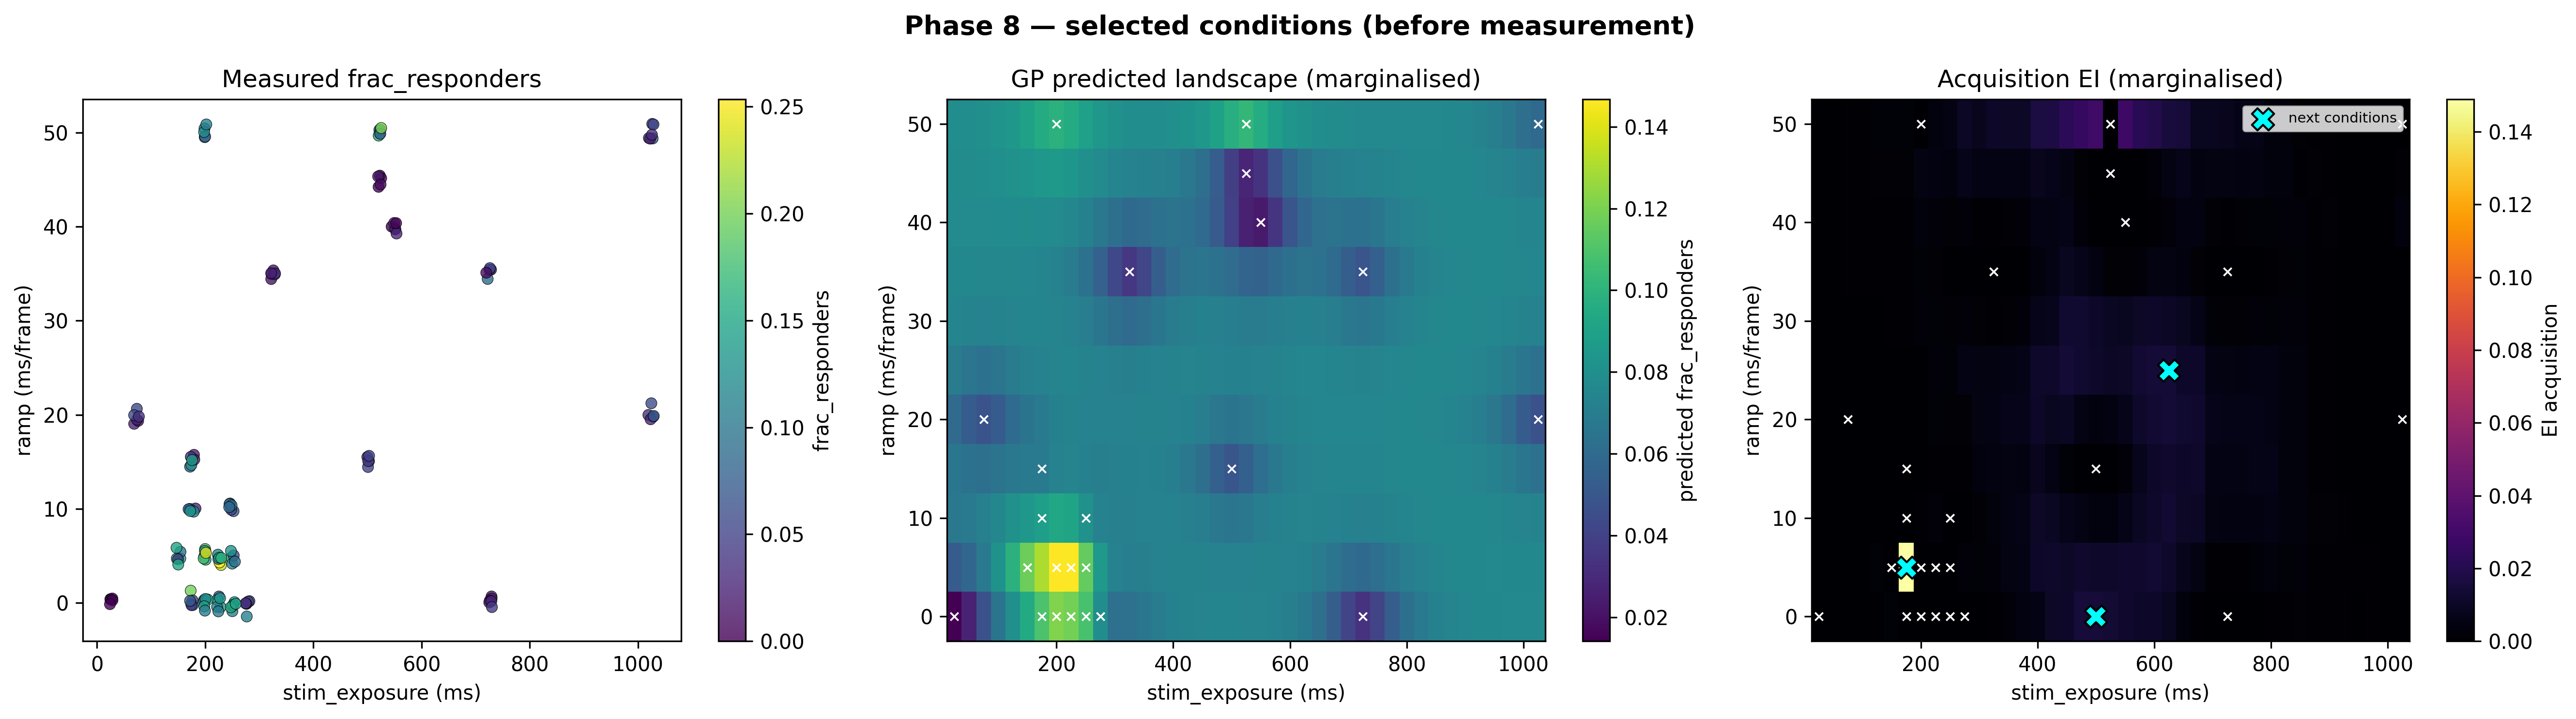

  Created 1620 events for phase 8
    Cond 0 (FOVs 144-149): stim_exposure=175ms, ramp=5ms/frame (final exposure: 470ms)
    Cond 1 (FOVs 150-155): stim_exposure=500ms, ramp=0ms/frame (final exposure: 500ms)
    Cond 2 (FOVs 156-161): stim_exposure=625ms, ramp=25ms/frame (final exposure: 2100ms)
  Phase 8: 17 FOVs, mean frac_oscillating=0.9987, max=1.0000


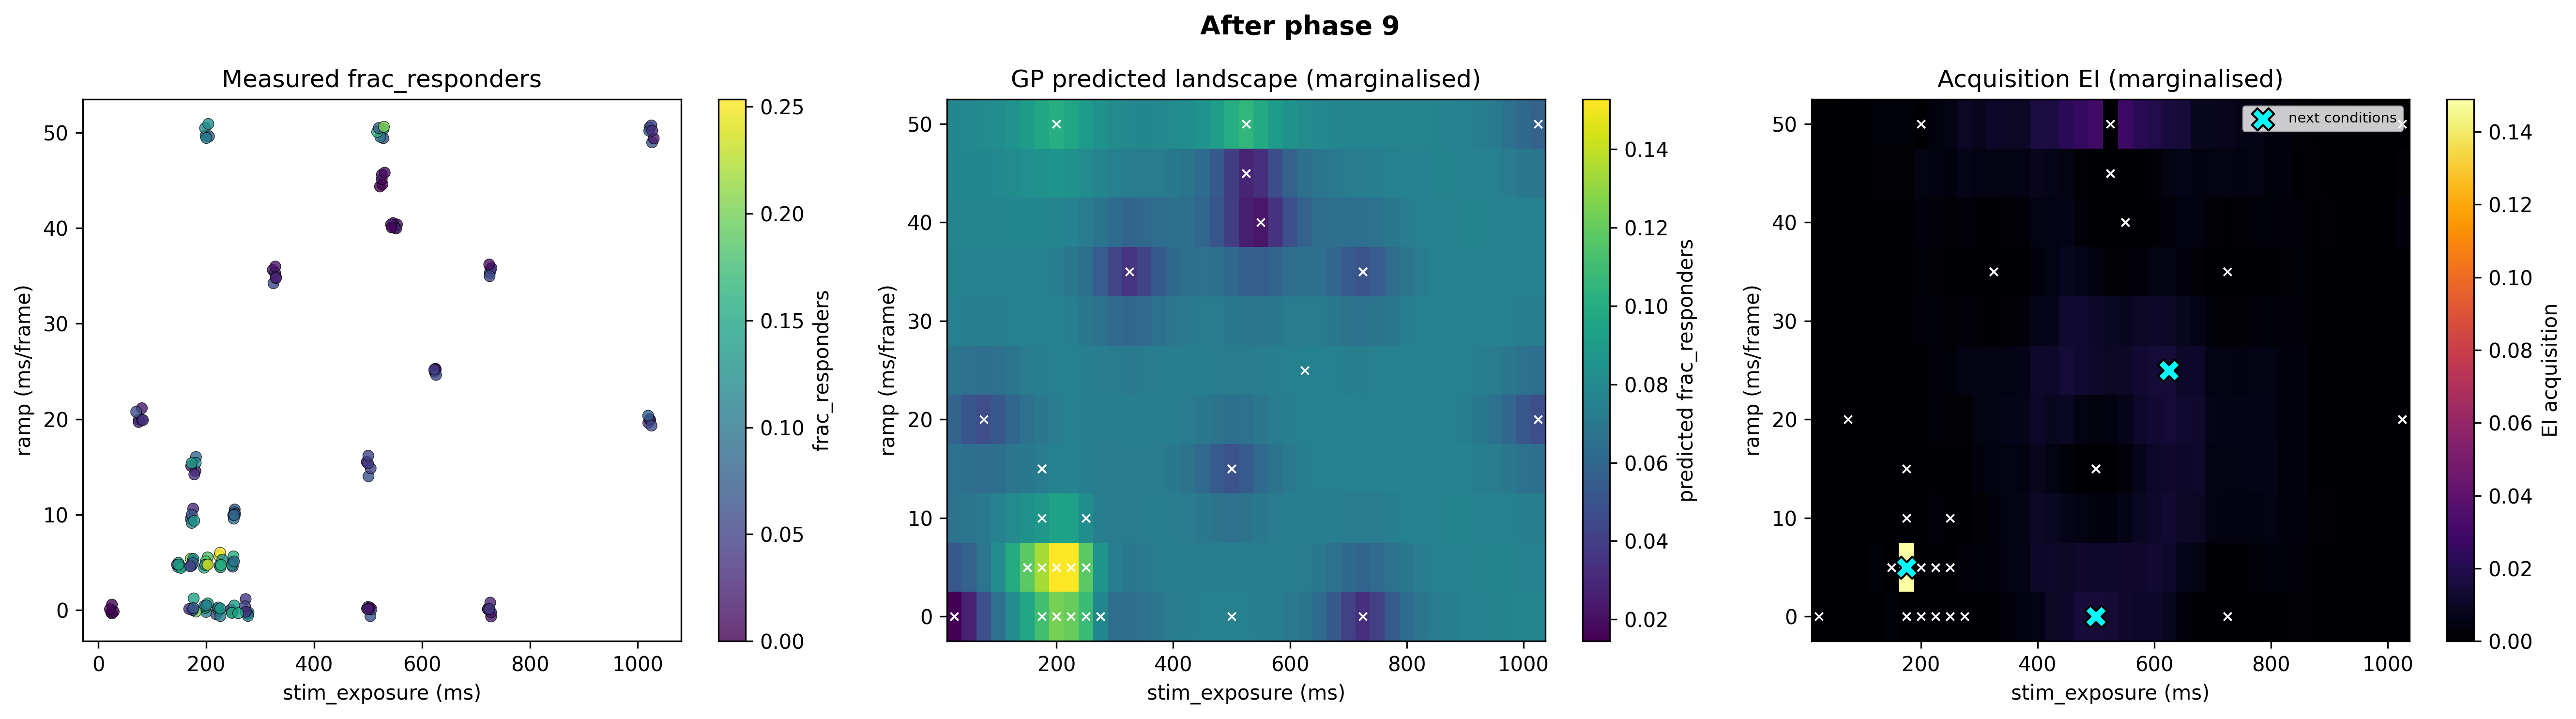


=== ComposedAgent: phase 10/12 ===
[FOVFinderAgent] Phase 9 — selected FOVs:
    A12_0000: 164 cells
    A12_0001: 90 cells
    A12_0002: 251 cells
    B12_0000: 45 cells
    B12_0001: 143 cells
    B12_0002: 276 cells
    B11_0000: 210 cells
    B11_0001: 279 cells
    B11_0002: 318 cells
    B10_0000: 260 cells
    B10_0001: 274 cells
    B10_0002: 270 cells
    B9_0000: 143 cells
    B9_0001: 315 cells
    B9_0002: 169 cells
    B8_0000: 218 cells
    B8_0001: 197 cells
    B8_0002: 177 cells


sample: 100%|##########| 1200/1200 [00:11<00:00, 103.61it/s, 7 steps of size 4.96e-01. acc. prob=0.93]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.12      0.05      0.11      0.05      0.19    710.50      1.00
k_length[1]      0.18      0.11      0.16      0.05      0.31    714.50      1.00
k_length[2]      2.45      0.89      2.26      1.11      3.66    704.40      1.00
k_length[3]      9.05      5.07      7.74      2.61     15.82    785.53      1.00
k_length[4]      6.27      4.04      5.24      1.98     10.87    455.92      1.00
    k_scale      0.62      0.17      0.59      0.35      0.88    722.17      1.00
      noise      0.30      0.05      0.30      0.22      0.38    899.02      1.00

Computing robust acquisition over 16960 scenarios (424 grid points x 40 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.385133
  Robust acq stats: min=0.000014, max=0.172720
  [reusing cached GP fit from earlier in this batch]
Computing robust acquisition over 16920 scenarios (423 grid points x 40 covariate samp

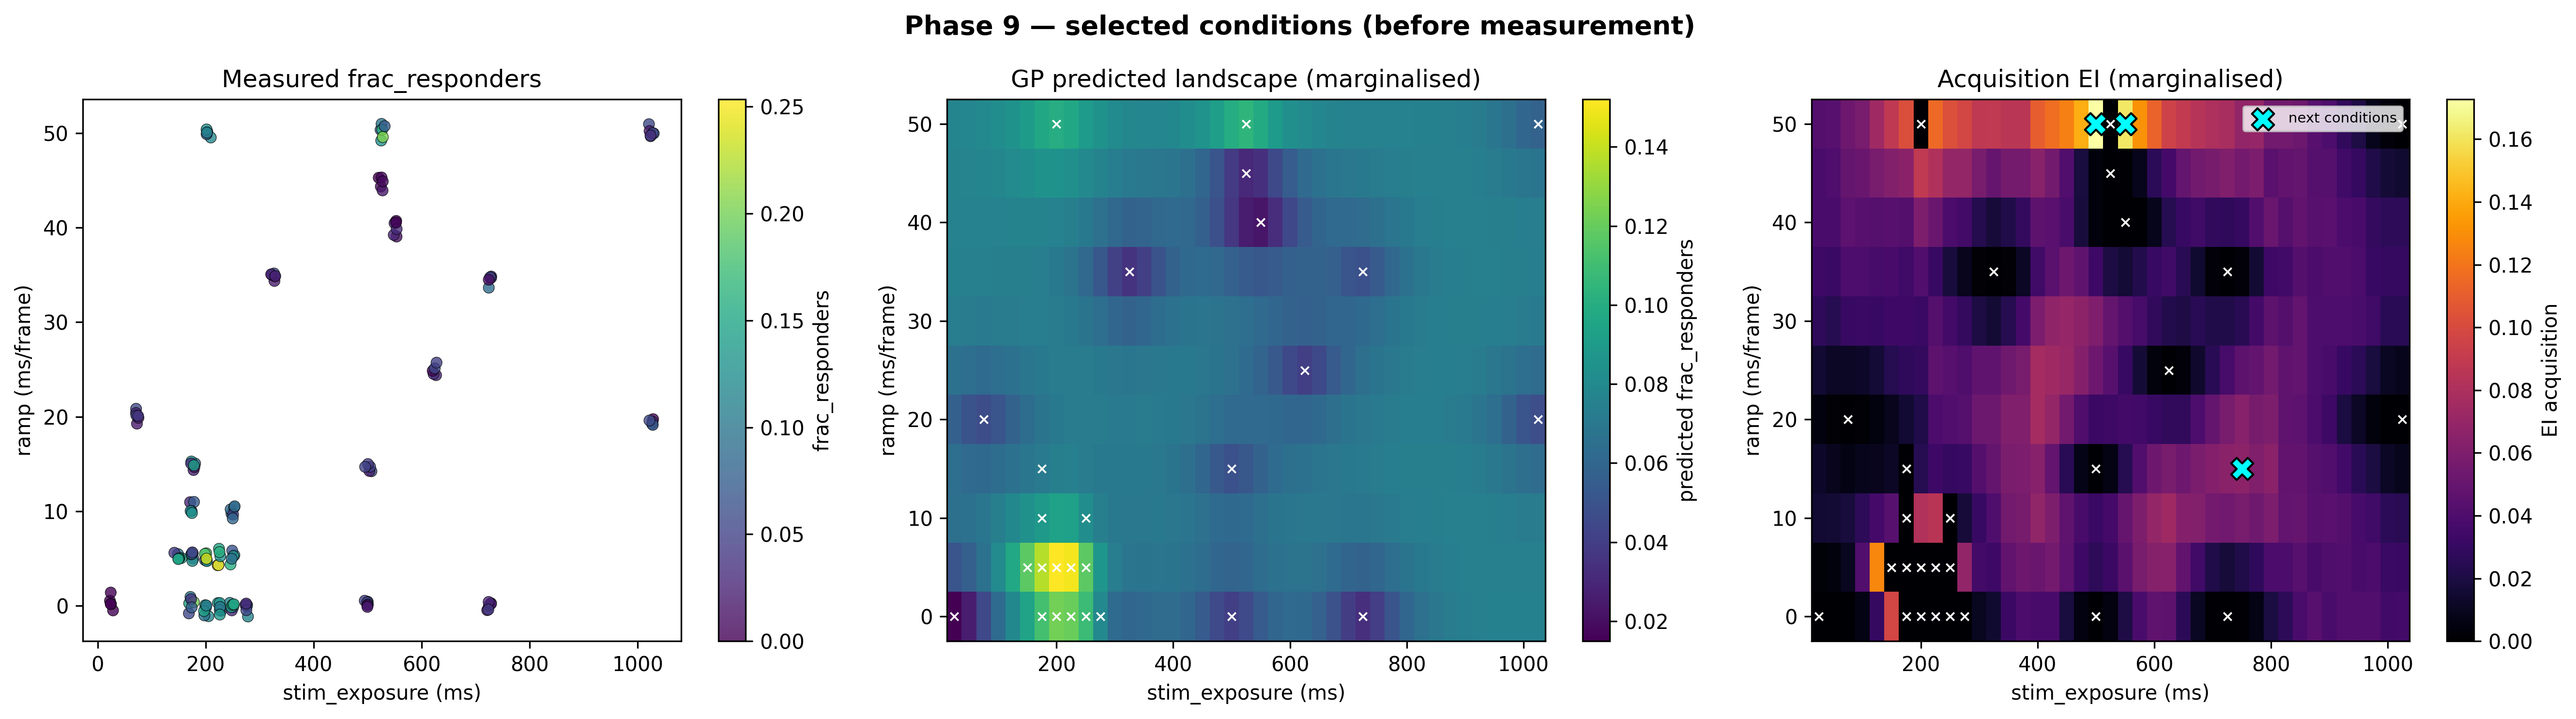

  Created 1620 events for phase 9
    Cond 0 (FOVs 162-167): stim_exposure=500ms, ramp=50ms/frame (final exposure: 3450ms)
    Cond 1 (FOVs 168-173): stim_exposure=550ms, ramp=50ms/frame (final exposure: 3500ms)
    Cond 2 (FOVs 174-179): stim_exposure=750ms, ramp=15ms/frame (final exposure: 1635ms)
  Phase 9: 17 FOVs, mean frac_oscillating=0.9995, max=1.0000


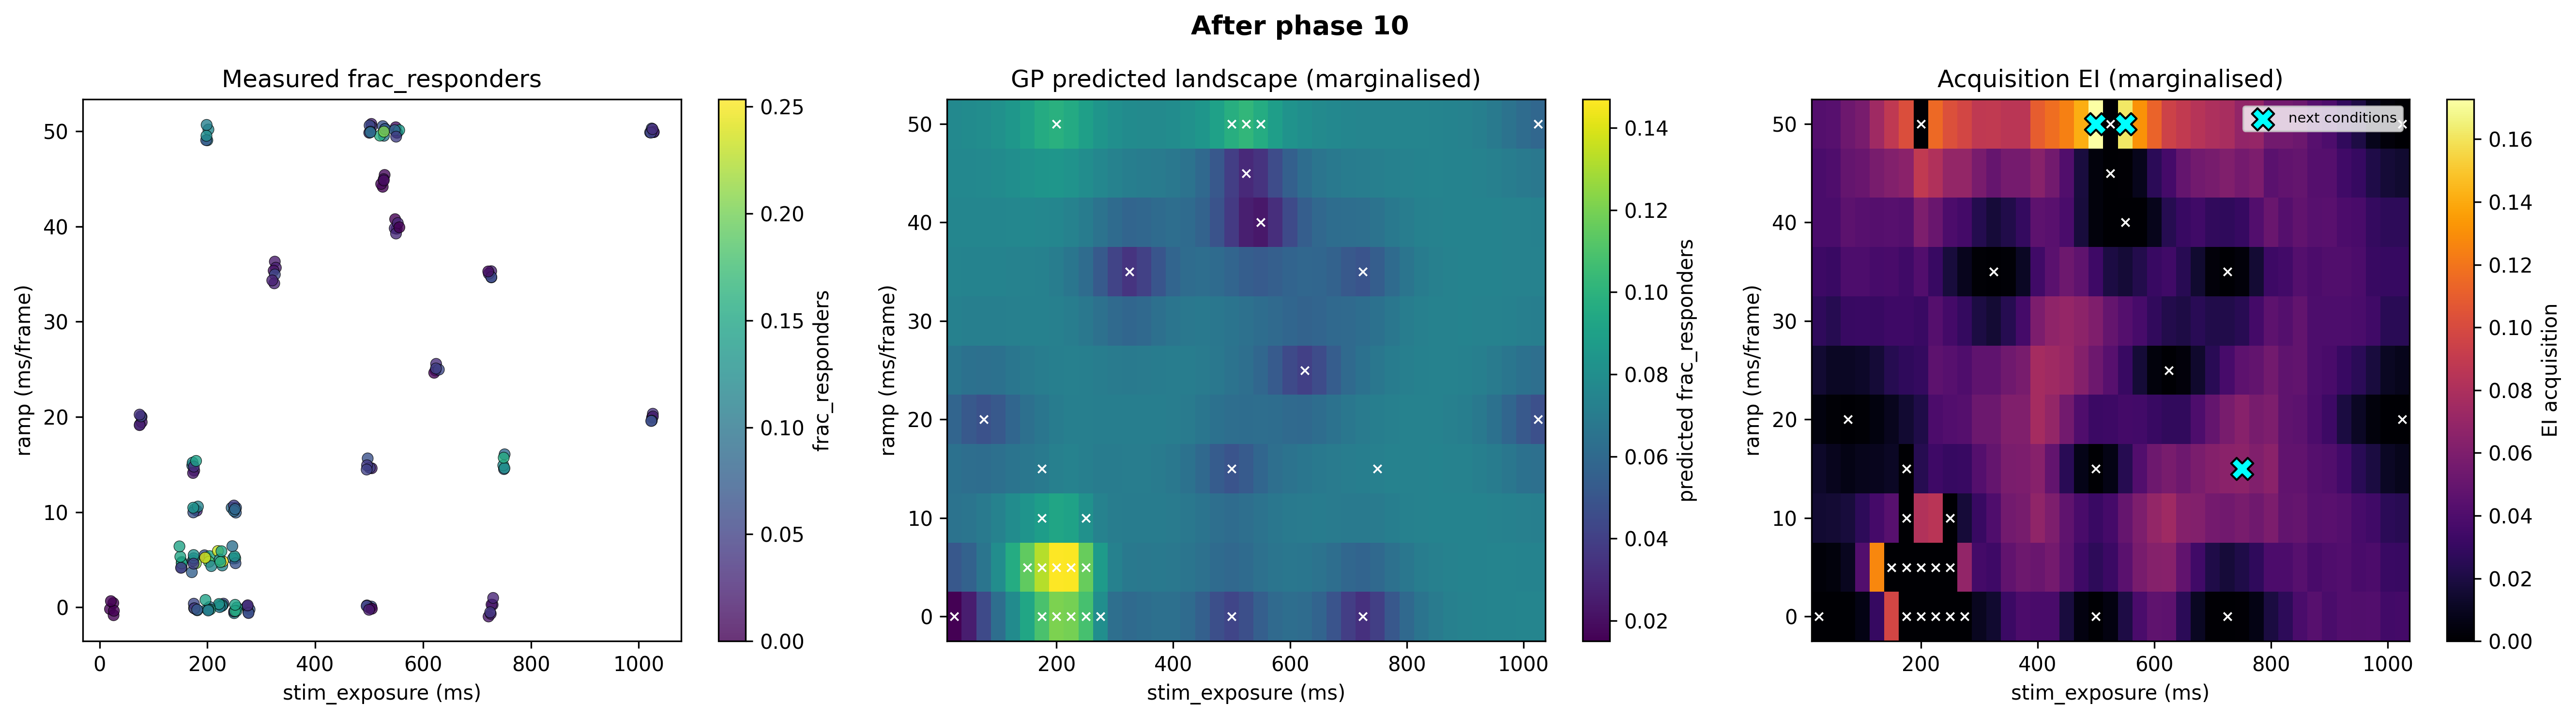


=== ComposedAgent: phase 11/12 ===
[FOVFinderAgent] Phase 10 — selected FOVs:
    B7_0000: 179 cells
    B7_0001: 241 cells
    B7_0002: 252 cells
    B6_0000: 278 cells
    B6_0001: 204 cells
    B6_0002: 179 cells
    B5_0000: 198 cells
    B5_0001: 236 cells
    B5_0002: 254 cells
    B4_0000: 225 cells
    B4_0001: 208 cells
    B4_0002: 264 cells
    B3_0000: 239 cells
    B3_0001: 153 cells
    B3_0002: 269 cells
    B2_0000: 334 cells
    B2_0001: 278 cells
    B2_0002: 262 cells


sample: 100%|##########| 1200/1200 [00:16<00:00, 72.52it/s, 7 steps of size 5.76e-01. acc. prob=0.90]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.09      0.04      0.08      0.04      0.14    860.69      1.00
k_length[1]      0.22      0.21      0.18      0.06      0.36    295.26      1.00
k_length[2]      2.41      0.87      2.21      1.22      3.69    677.16      1.00
k_length[3]      7.24      4.15      6.22      2.28     12.28    869.68      1.00
k_length[4]      5.48      3.50      4.47      1.74      9.39    450.39      1.00
    k_scale      0.61      0.17      0.58      0.32      0.82    793.31      1.00
      noise      0.33      0.06      0.32      0.23      0.41    637.65      1.00

Computing robust acquisition over 16840 scenarios (421 grid points x 40 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.390256
  Robust acq stats: min=0.001380, max=0.219903
  [reusing cached GP fit from earlier in this batch]
Computing robust acquisition over 16800 scenarios (420 grid points x 40 covariate samp

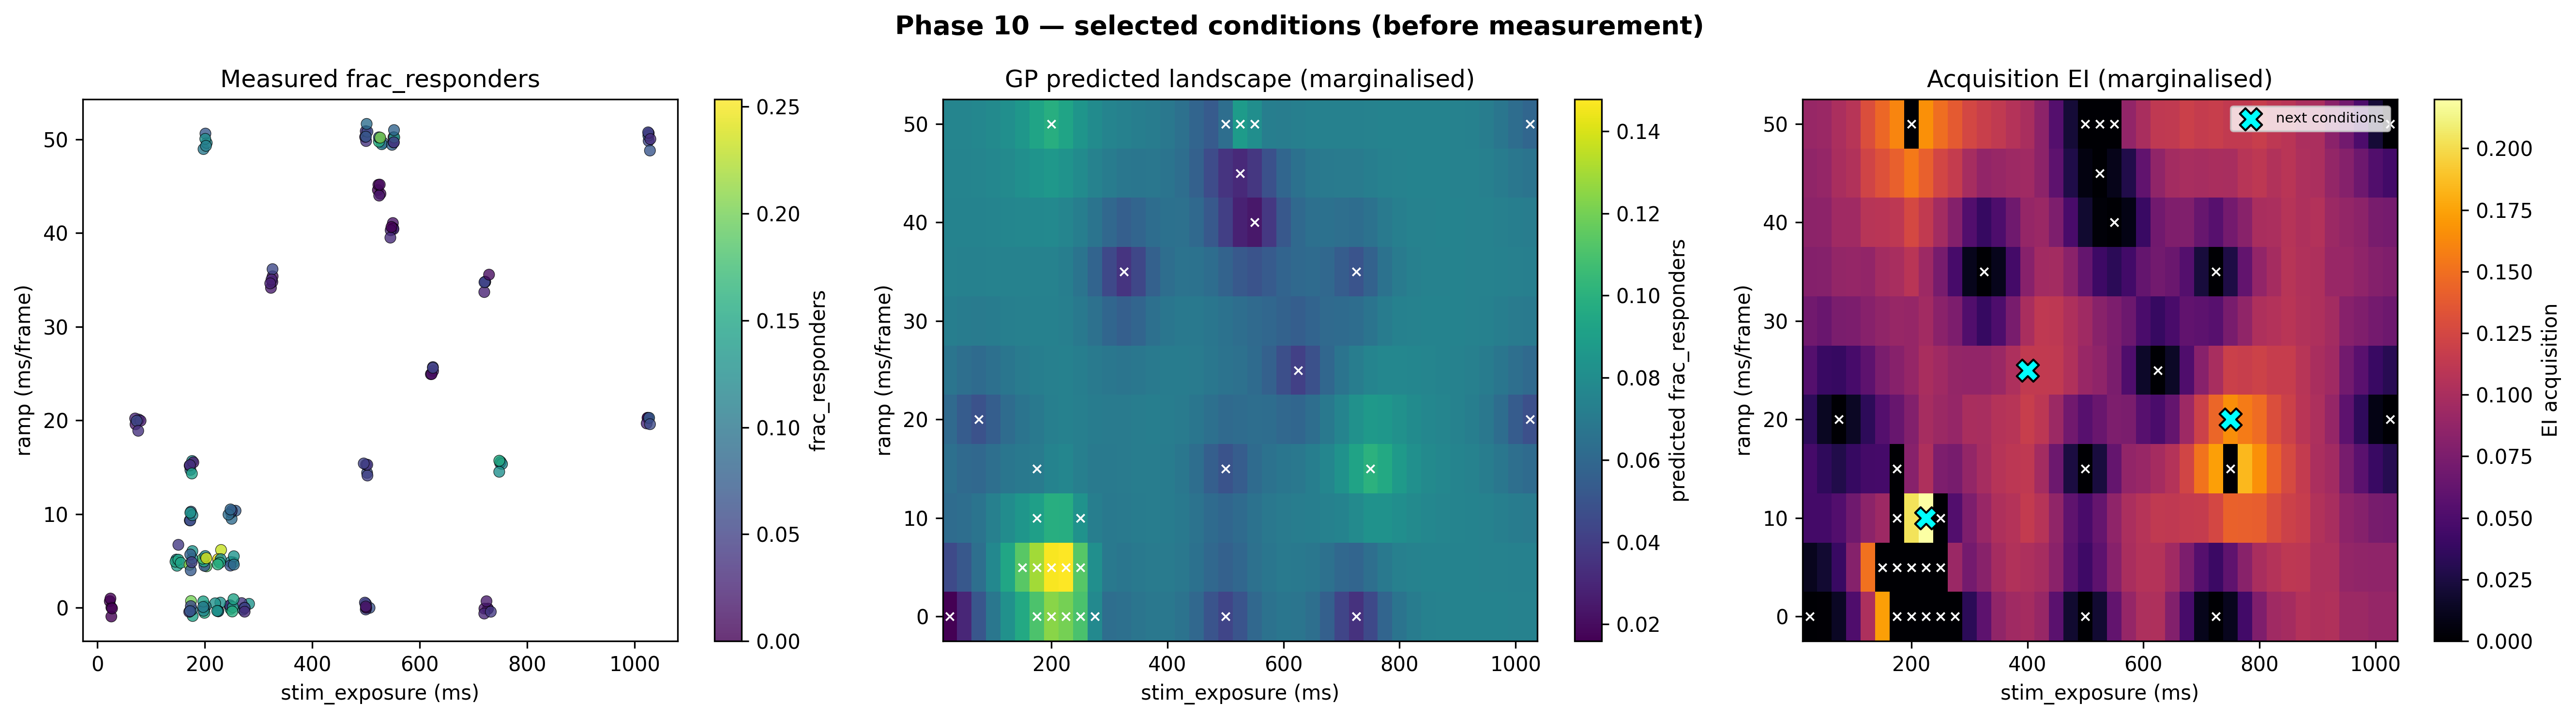

  Created 1620 events for phase 10
    Cond 0 (FOVs 180-185): stim_exposure=225ms, ramp=10ms/frame (final exposure: 815ms)
    Cond 1 (FOVs 186-191): stim_exposure=400ms, ramp=25ms/frame (final exposure: 1875ms)
    Cond 2 (FOVs 192-197): stim_exposure=750ms, ramp=20ms/frame (final exposure: 1930ms)
  Phase 10: 17 FOVs, mean frac_oscillating=0.9995, max=1.0000


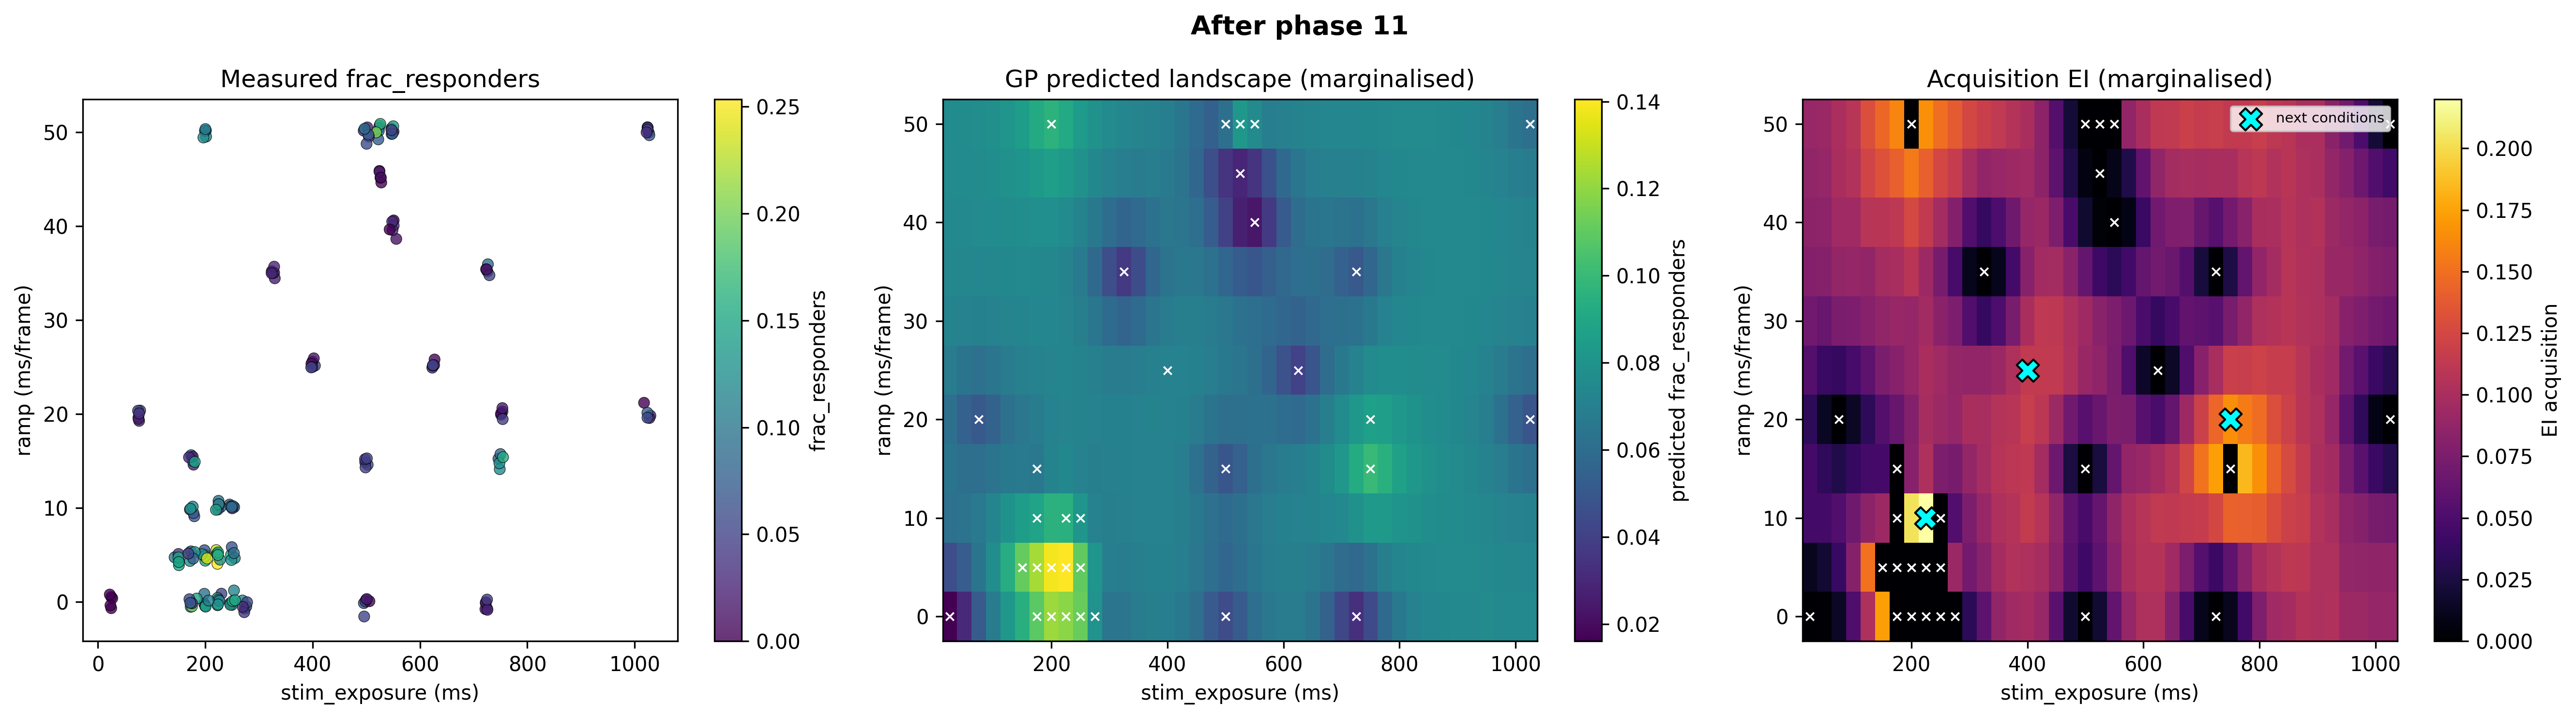


=== ComposedAgent: phase 12/12 ===
[FOVFinderAgent] Phase 11 — selected FOVs:
    C2_0000: 394 cells
    C2_0001: 179 cells
    C2_0002: 160 cells
    C3_0000: 283 cells
    C3_0001: 259 cells
    C3_0002: 248 cells
    C4_0000: 226 cells
    C4_0001: 166 cells
    C4_0002: 264 cells
    C5_0000: 240 cells
    C5_0001: 221 cells
    C5_0002: 181 cells
    C6_0000: 277 cells
    C6_0001: 181 cells
    C6_0002: 246 cells
    C7_0000: 359 cells
    C7_0001: 204 cells
    C7_0002: 198 cells


sample: 100%|##########| 1200/1200 [00:28<00:00, 42.81it/s, 7 steps of size 5.79e-01. acc. prob=0.91]



                 mean       std    median      5.0%     95.0%     n_eff     r_hat
k_length[0]      0.10      0.05      0.09      0.05      0.16    517.22      1.00
k_length[1]      0.18      0.08      0.17      0.06      0.28    479.26      1.00
k_length[2]      2.55      0.92      2.37      1.27      3.86    671.14      1.00
k_length[3]      7.07      4.15      6.00      2.03     12.33    801.29      1.00
k_length[4]      5.84      3.67      4.91      1.86      9.85    493.61      1.00
    k_scale      0.59      0.16      0.58      0.34      0.83    932.18      1.00
      noise      0.34      0.05      0.33      0.25      0.42    534.54      1.00

Computing robust acquisition over 16720 scenarios (418 grid points x 40 covariate samples)...
  best_f (scaled, from GP predicted mean over grid): 0.443013
  Robust acq stats: min=0.000075, max=0.122539
  [reusing cached GP fit from earlier in this batch]
Computing robust acquisition over 16680 scenarios (417 grid points x 40 covariate samp

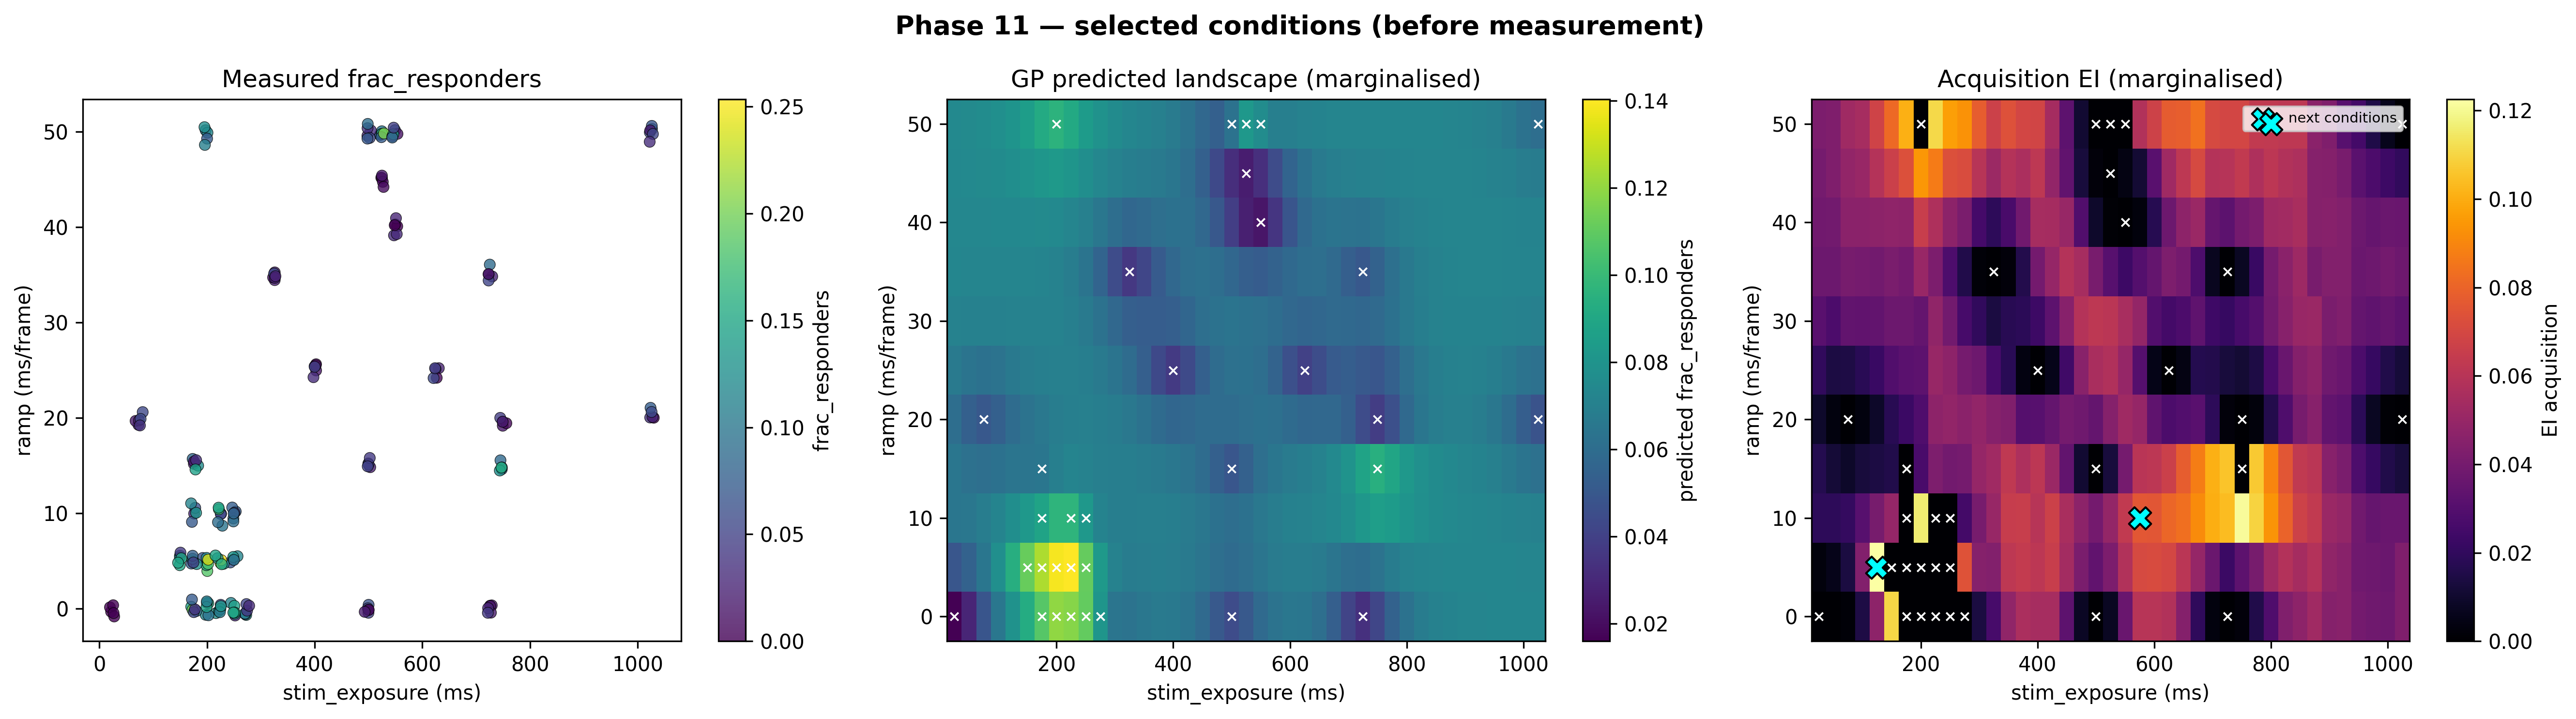

  Created 1620 events for phase 11
    Cond 0 (FOVs 198-203): stim_exposure=125ms, ramp=5ms/frame (final exposure: 420ms)
    Cond 1 (FOVs 204-209): stim_exposure=800ms, ramp=50ms/frame (final exposure: 3750ms)
    Cond 2 (FOVs 210-215): stim_exposure=575ms, ramp=10ms/frame (final exposure: 1165ms)
  Phase 11: 17 FOVs, mean frac_oscillating=0.9986, max=1.0000


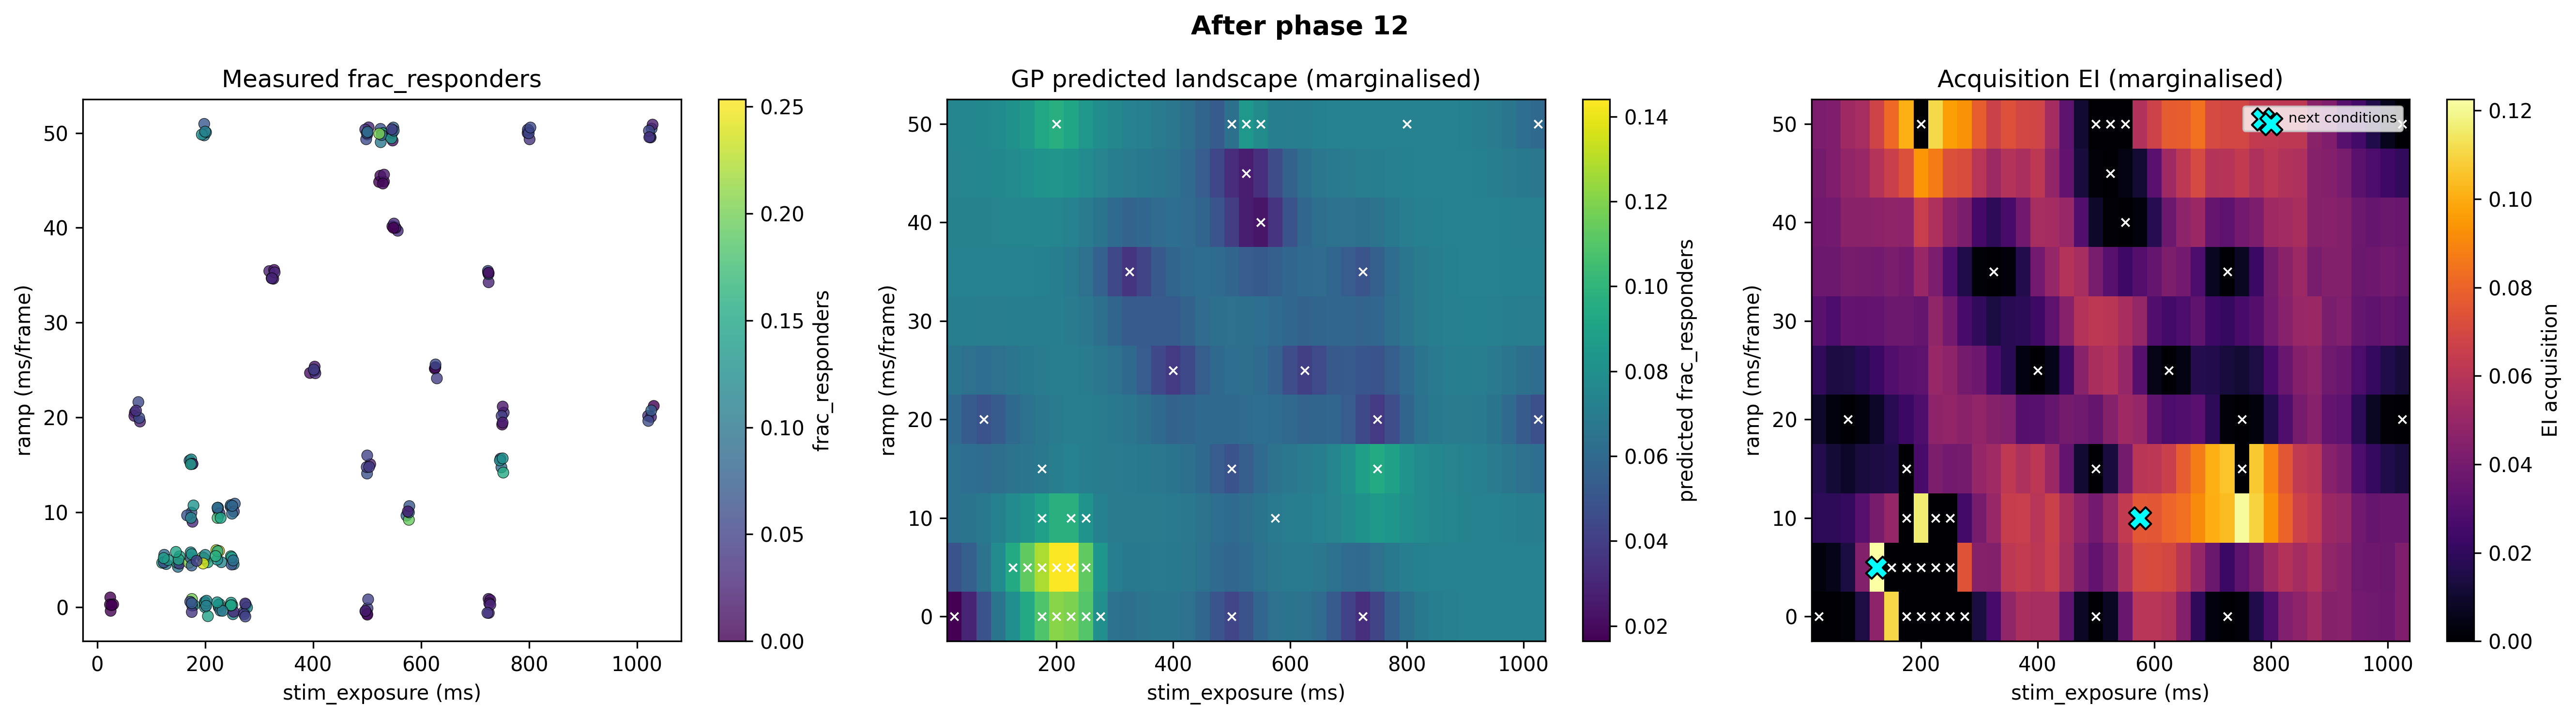

In [7]:
# --- Run the composed (FOV finder + BO) loop ---
# Each phase: FOVFinder picks 18 fresh FOVs (3 FOVs in 6 fresh wells), then
# OscillationBO runs one batch BO iteration over those FOVs.  The GP
# accumulates observations across all phases.


# Disconnect napari live view so it does not interfere with the acquisition engine
try:
    mm_wdg._core_link.cleanup()
except:
    pass

# sleep_time = 3600*10 # sleep until tomorrow morning
# for t in range(0, sleep_time):
#    time.sleep(1)


composed_agent.run()

In [8]:
# Post-processing: merge per-FOV tracks
utils.generate_exp_data_from_tracks(path)

## Visualise results

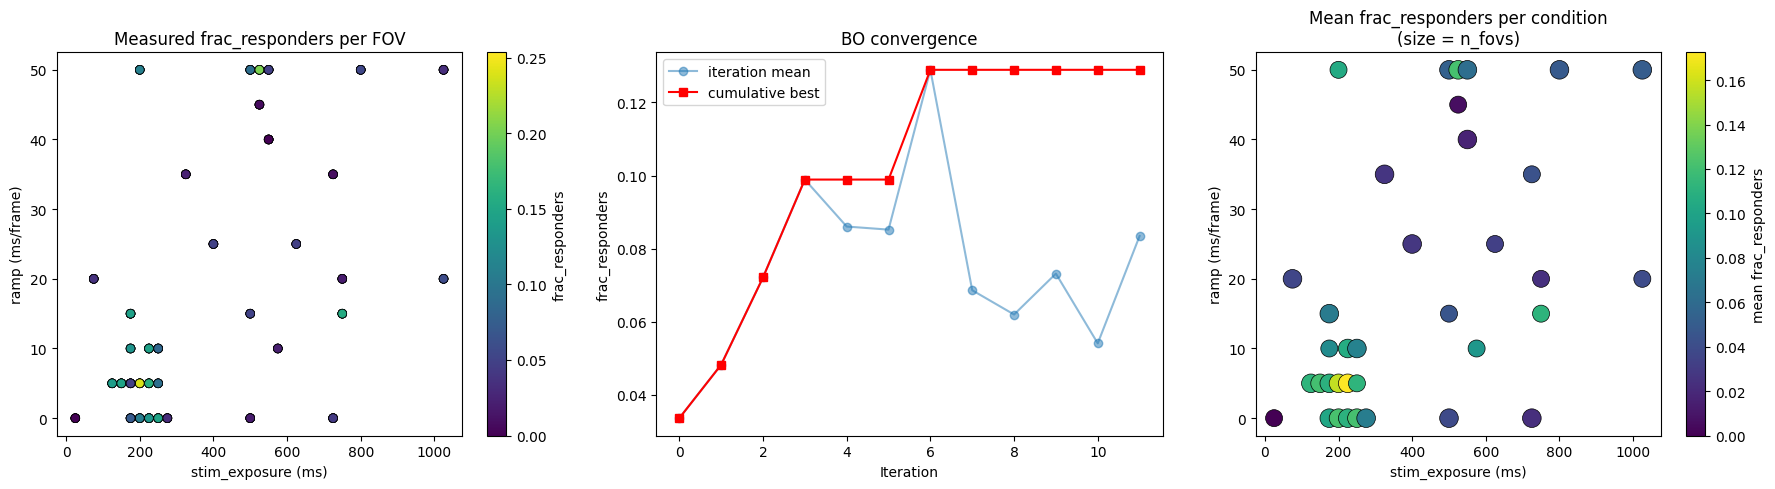


Best condition (by mean across FOVs):
  stim_exposure = 225 ms
  ramp = 5 ms/frame
  mean frac_responders = 0.1725
  tested on 6 FOVs


In [9]:
if agent.df_results is not None and not agent.df_results.empty:
    df = agent.df_results

    fig, axes = plt.subplots(1, 3, figsize=(18, 5))

    # 1. Scatter: stim_exposure vs ramp, colored by frac_responders
    sc = axes[0].scatter(
        df["stim_exposure"],
        df["ramp"],
        c=df["frac_responders"],
        cmap="viridis",
        s=40,
        edgecolors="k",
        linewidths=0.5,
    )
    axes[0].set_xlabel("stim_exposure (ms)")
    axes[0].set_ylabel("ramp (ms/frame)")
    axes[0].set_title("Measured frac_responders per FOV")
    fig.colorbar(sc, ax=axes[0], label="frac_responders")

    # 2. Convergence: best frac_responders over iterations
    if agent._iteration_means:
        means = np.array(agent._iteration_means)
        cumulative_best = np.maximum.accumulate(means)
        axes[1].plot(means, "o-", alpha=0.5, label="iteration mean")
        axes[1].plot(cumulative_best, "s-", color="red", label="cumulative best")
        axes[1].set_xlabel("Iteration")
        axes[1].set_ylabel("frac_responders")
        axes[1].set_title("BO convergence")
        axes[1].legend()

    # 3. Per-condition aggregation: mean frac_responders per (stim_exposure, ramp)
    cond_agg = (
        df.groupby(["stim_exposure", "ramp"])
        .agg(
            mean_frac=("frac_responders", "mean"),
            n_fovs=("frac_responders", "count"),
        )
        .reset_index()
    )
    sc2 = axes[2].scatter(
        cond_agg["stim_exposure"],
        cond_agg["ramp"],
        c=cond_agg["mean_frac"],
        s=cond_agg["n_fovs"] * 30,
        cmap="viridis",
        edgecolors="k",
        linewidths=0.5,
    )
    axes[2].set_xlabel("stim_exposure (ms)")
    axes[2].set_ylabel("ramp (ms/frame)")
    axes[2].set_title("Mean frac_responders per condition\n(size = n_fovs)")
    fig.colorbar(sc2, ax=axes[2], label="mean frac_responders")

    plt.tight_layout()
    plt.show()

    # Print best condition
    best_idx = cond_agg["mean_frac"].idxmax()
    best = cond_agg.loc[best_idx]
    print(f"\nBest condition (by mean across FOVs):")
    print(f"  stim_exposure = {best['stim_exposure']:.0f} ms")
    print(f"  ramp = {best['ramp']:.0f} ms/frame")
    print(f"  mean frac_responders = {best['mean_frac']:.4f}")
    print(f"  tested on {int(best['n_fovs'])} FOVs")
else:
    print("No data collected yet.")

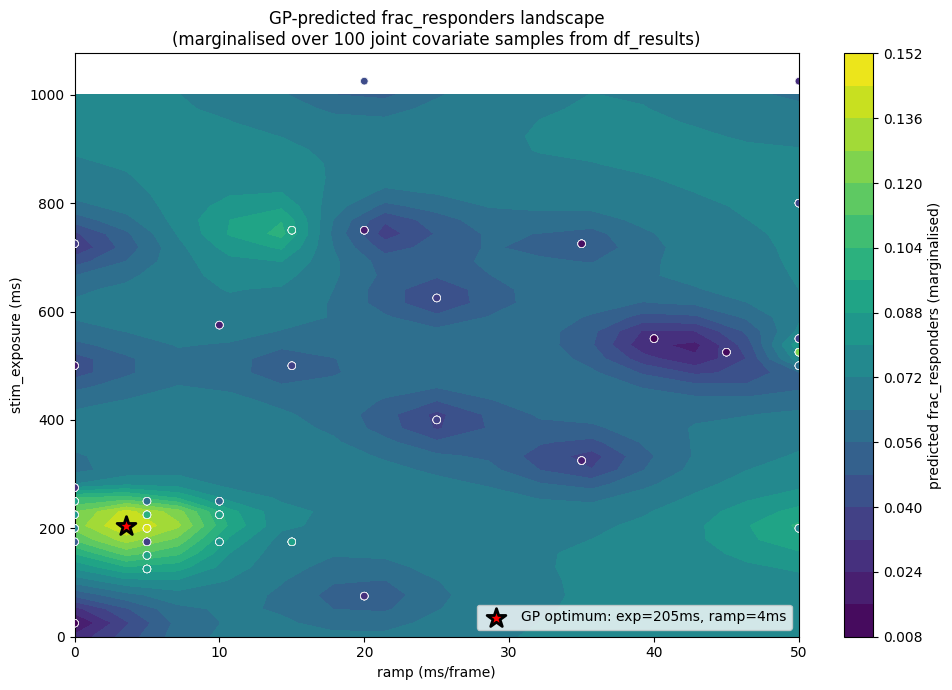

GP-predicted optimum (marginalised over covariates):
  stim_exposure = 205 ms
  ramp = 4 ms/frame
  predicted frac_responders = 0.1451


In [10]:
# GP-predicted landscape, marginalised over covariates the SAME way the BO
# acquisition does: average GP predictions over joint samples from the
# empirical covariate distribution (preserves n_cells / optortk_expression
# correlations). This computes E_c[mu(x, c)] instead of the biased plug-in
# mu(x, median(c)).
import gpax
import gpax.utils

if agent.model is not None and agent.x is not None:
    rng_key, rng_key_pred = gpax.utils.get_keys()

    # Controllable-parameter grid
    exp_vals = np.linspace(0.0, 1000.0, 40)
    ramp_vals = np.linspace(0.0, 50.0, 15)
    ctrl_grid = np.array([[e, r] for e in exp_vals for r in ramp_vals])
    n_grid = ctrl_grid.shape[0]

    # Joint covariate samples from df_results (correlations preserved).
    # We intentionally resample directly from df_results here (rather than
    # calling agent._sample_covariate_grid, which is capped at n_cov_samples)
    # to get a denser MC estimate for the plot without touching the agent's
    # internal RNG state.
    df = agent.df_results
    n_cov_samples = 100
    cov_vals_full = df[[c.name for c in agent.bo_covariates]].to_numpy(dtype=float)
    if cov_vals_full.shape[0] == 0:
        raise RuntimeError("No covariate observations available for marginalisation.")
    _rng = np.random.default_rng(0)
    idx = _rng.integers(0, cov_vals_full.shape[0], size=n_cov_samples)
    cov_samples = cov_vals_full[idx]  # (n_cov_samples, n_covariates), joint

    # Build (x, c) full input: repeat each ctrl row n_cov_samples times and
    # tile the covariate samples across all ctrl rows. Mirrors the layout
    # used in BOptGPAX._compute_robust_acq.
    x_full = np.hstack(
        [
            np.repeat(ctrl_grid, n_cov_samples, axis=0),
            np.tile(cov_samples, (n_grid, 1)),
        ]
    )
    x_full_scaled = agent._x_scaler.transform(x_full)

    y_pred_scaled, _ = agent.model.predict(rng_key_pred, x_full_scaled, noiseless=True)
    y_pred = agent._y_scaler.inverse_transform(
        np.asarray(y_pred_scaled).reshape(-1, 1)
    ).flatten()

    # Marginalise over covariates: E_c[mu(x, c)] via Monte-Carlo mean over
    # joint covariate samples. This matches the BO acquisition target
    # (cov_marginalization_mode='joint').
    y_pred_marg = y_pred.reshape(n_grid, n_cov_samples).mean(axis=1)
    Y_grid = y_pred_marg.reshape(len(exp_vals), len(ramp_vals))

    fig, ax = plt.subplots(1, 1, figsize=(10, 7))
    cf = ax.contourf(ramp_vals, exp_vals, Y_grid, levels=20, cmap="viridis")
    fig.colorbar(cf, ax=ax, label="predicted frac_responders (marginalised)")

    # Overlay measured points
    ax.scatter(
        df["ramp"],
        df["stim_exposure"],
        c=df["frac_responders"],
        cmap="viridis",
        s=30,
        edgecolors="white",
        linewidths=0.5,
        zorder=5,
    )

    # Mark GP optimum on the marginalised landscape
    opt_idx = int(np.argmax(y_pred_marg))
    opt_exp = ctrl_grid[opt_idx, 0]
    opt_ramp = ctrl_grid[opt_idx, 1]
    ax.scatter(
        opt_ramp,
        opt_exp,
        c="red",
        s=200,
        marker="*",
        edgecolors="black",
        linewidths=2,
        zorder=10,
        label=f"GP optimum: exp={opt_exp:.0f}ms, ramp={opt_ramp:.0f}ms",
    )

    ax.set_xlabel("ramp (ms/frame)")
    ax.set_ylabel("stim_exposure (ms)")
    ax.set_title(
        "GP-predicted frac_responders landscape\n"
        f"(marginalised over {n_cov_samples} joint covariate samples "
        f"from df_results)"
    )
    ax.legend(loc="lower right")
    plt.tight_layout()
    plt.show()

    print("GP-predicted optimum (marginalised over covariates):")
    print(f"  stim_exposure = {opt_exp:.0f} ms")
    print(f"  ramp = {opt_ramp:.0f} ms/frame")
    print(f"  predicted frac_responders = {float(y_pred_marg[opt_idx]):.4f}")

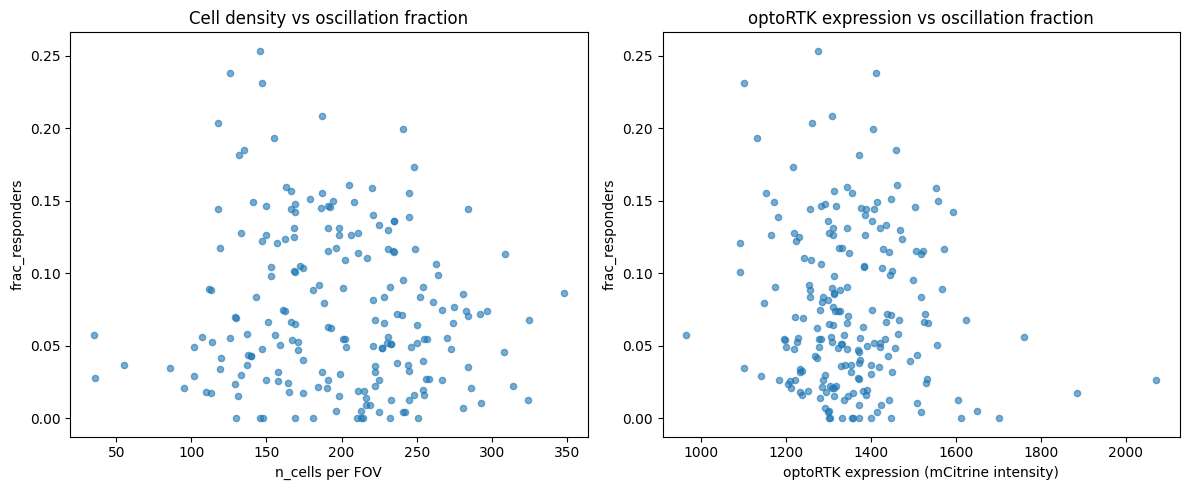

In [11]:
# Covariate effects: how n_cells and optoRTK expression affect oscillation fraction
if agent.df_results is not None and not agent.df_results.empty:
    df = agent.df_results

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))

    axes[0].scatter(df["n_cells"], df["frac_responders"], alpha=0.6, s=20)
    axes[0].set_xlabel("n_cells per FOV")
    axes[0].set_ylabel("frac_responders")
    axes[0].set_title("Cell density vs oscillation fraction")

    axes[1].scatter(df["optortk_expression"], df["frac_responders"], alpha=0.6, s=20)
    axes[1].set_xlabel("optoRTK expression (mCitrine intensity)")
    axes[1].set_ylabel("frac_responders")
    axes[1].set_title("optoRTK expression vs oscillation fraction")

    plt.tight_layout()
    plt.show()

In [12]:
import pandas as pd
import glob, os

RUN_PATH = r"E:\Alex\2026-04-14_bo_erk_oscillation_v6_test"
ckpts = sorted(
    glob.glob(os.path.join(RUN_PATH, "checkpoints", "bo_results_phase_*.parquet"))
)

# Build per-phase deltas: each checkpoint contains cumulative df_results,
# so phase N's new conditions = rows in ckpt N that aren't in ckpt N-1
prev_len = 0
summary = []
for f in ckpts:
    phase_id = int(os.path.basename(f).split("_")[-1].split(".")[0])
    df = pd.read_parquet(f)
    df_new = df.iloc[prev_len:]
    prev_len = len(df)
    conds = df_new[["stim_exposure", "ramp"]].drop_duplicates().values.tolist()
    summary.append(
        {
            "phase_id": phase_id,
            "n_fovs": len(df_new),
            "conditions": [f"({int(s)}ms, ramp={int(r)})" for s, r in conds],
        }
    )

for row in summary:
    print(
        f"Phase {row['phase_id']:2d}  ({row['n_fovs']:2d} FOVs): "
        f"{'  |  '.join(row['conditions'])}"
    )

Phase  0  (14 FOVs): (85ms, ramp=12)  |  (725ms, ramp=34)
Phase  1  (18 FOVs): (725ms, ramp=0)  |  (255ms, ramp=34)
Phase  2  (18 FOVs): (265ms, ramp=8)  |  (325ms, ramp=24)
Phase  3  (18 FOVs): (175ms, ramp=38)  |  (305ms, ramp=40)
Phase  4  (18 FOVs): (515ms, ramp=12)  |  (195ms, ramp=24)
Phase  5  (18 FOVs): (775ms, ramp=48)  |  (705ms, ramp=20)
Phase  6  (18 FOVs): (385ms, ramp=32)  |  (25ms, ramp=4)
Phase  7  (18 FOVs): (1005ms, ramp=26)  |  (465ms, ramp=28)
